### Import packages

In [ ]:
import pandas as pd
from datetime import timedelta
import numpy as np
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import grangercausalitytests

### Import data

In [78]:
df_daily=pd.read_excel(r'C:\Users\Peet\Downloads\DAILY DATA GFI.xlsx')
df_weekly=pd.read_excel(r'C:\Users\Peet\Downloads\YEAR DATA GFI.xlsx')

### Create daily data

In [79]:
# ――――――――――――――――――――――――――――――――――――――――――――――――――――――
# Fill in all missing calendar days and back-fill values.
# Assumes `df_trends` already exists and has a 'date' column.
# No classes, just straight-line Pandas.
# ――――――――――――――――――――――――――――――――――――――――――――――――――――――
import pandas as pd

# 1) make sure the date column is real datetime and sorted
df_weekly["Date"] = pd.to_datetime(df_weekly["Date"])
df_weekly = df_weekly.sort_values("Date")

# 2) set as index so reindexing is easy
df_weekly = df_weekly.set_index("Date")

# 3) build the full DAILY date range from min → max
full_index = pd.date_range(
    start=df_weekly.index.min(),
    end=df_weekly.index.max(),
    freq="D",          # change to "W" or "W-MON" if you only need weekly rows
)

# 4) reindex → insert missing rows, then back-fill every column
df_weekly = df_weekly.reindex(full_index).ffill()

# 5) restore the date column if you prefer a column instead of an index
df_weekly = df_weekly.reset_index().rename(columns={"index": "Date"})

In [80]:
# 1. Make sure the date columns are real columns, not the index
df_weekly = df_weekly.reset_index(drop=True)
df_daily        = df_daily.reset_index(drop=True)

# 2. Convert to datetime (good practice before any time‐based work)
df_weekly["Date"]  = pd.to_datetime(df_weekly["Date"])
df_daily["Date"]        = pd.to_datetime(df_daily["Date"])

# 3. Merge: 'Day' from df_trends with 'Date' from df
df = df_weekly.merge(df_daily,
                            how="left",
                            left_on="Date",   # column in df_trends
                            right_on="Date",suffixes=('_weekly','_daily')) # column in df

In [81]:
# Loop through all daily columns
for col in df.columns:
    if col.endswith('_daily'):
        base_name = col[:-6]  # Remove '_daily'
        weekly_col = base_name + '_weekly'
        
        if weekly_col in df.columns:  # Ensure matching weekly column exists
            adjusted_col = 'adjusted_daily_' + base_name
            df[adjusted_col] = df[col] * (df[weekly_col] / 100)

In [82]:
df = df[['Date'] + [col for col in df.columns if col.startswith('adjusted_daily_')]]

### Import stock data

In [83]:
df_stock = yf.download('GFI', start='2024-01-01', end='2025-01-01', interval='1d',multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


### Join trends and stock data

In [84]:
# 1. Make sure the date columns are real columns, not the index
df_weekly = df_weekly.reset_index(drop=True)
df_daily        = df_daily.reset_index(drop=True)

# 2. Convert to datetime (good practice before any time‐based work)
df_weekly["Date"]  = pd.to_datetime(df_weekly["Date"])
df_daily["Date"]        = pd.to_datetime(df_daily["Date"])

# 3. Merge: 'Day' from df_trends with 'Date' from df
df = df.merge(df_stock,
                            how="left",
                            left_on="Date",   # column in df_trends
                            right_on="Date",suffixes=('_weekly','_daily')) # column in df

In [85]:
df.drop(columns=['High','Low','Open','Volume'],inplace=True)

In [86]:
df.dropna(inplace=True)

### Visualise both stock prices and Google Trends data as time series with a 95% confidence

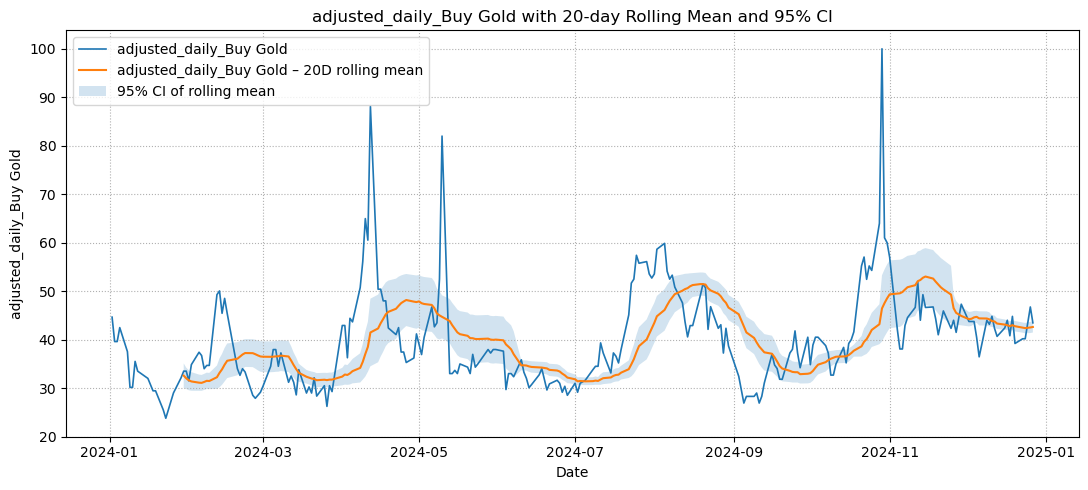

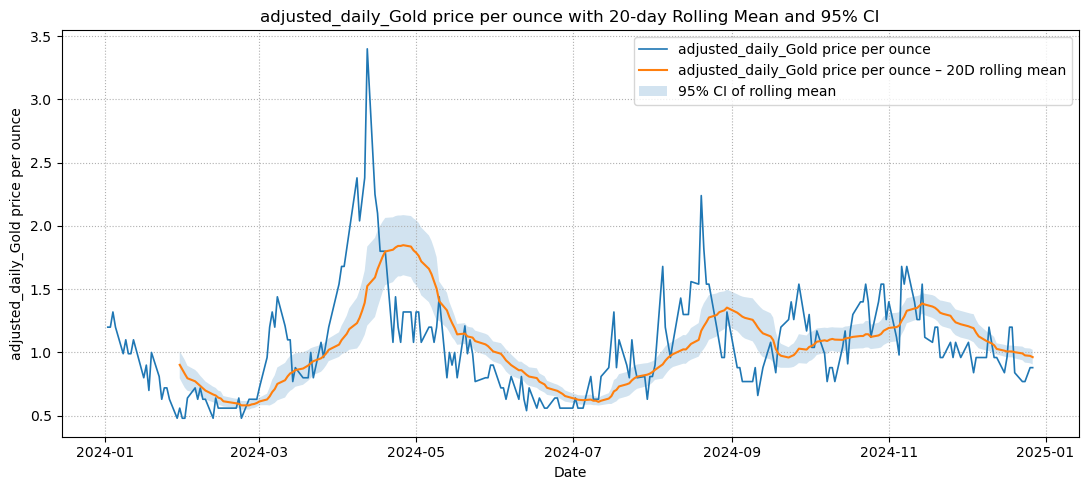

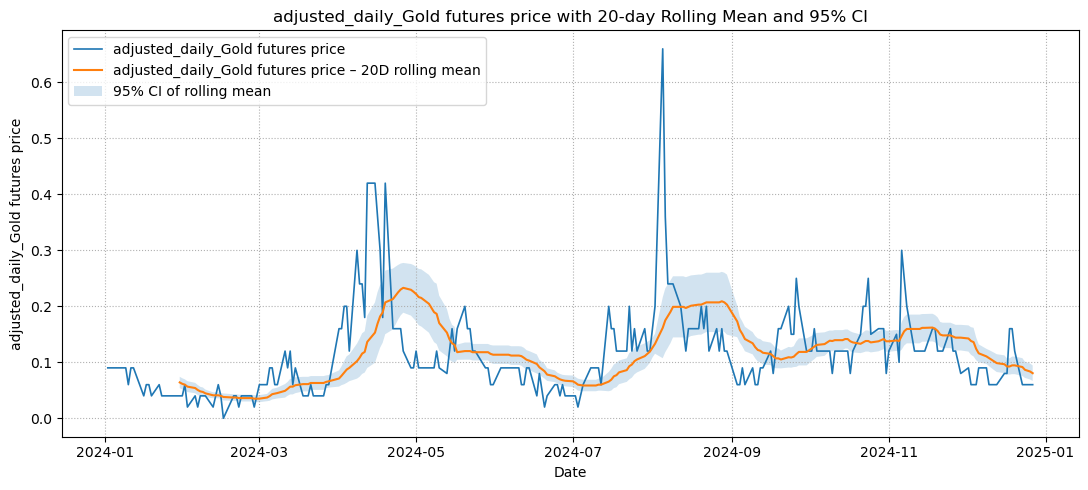

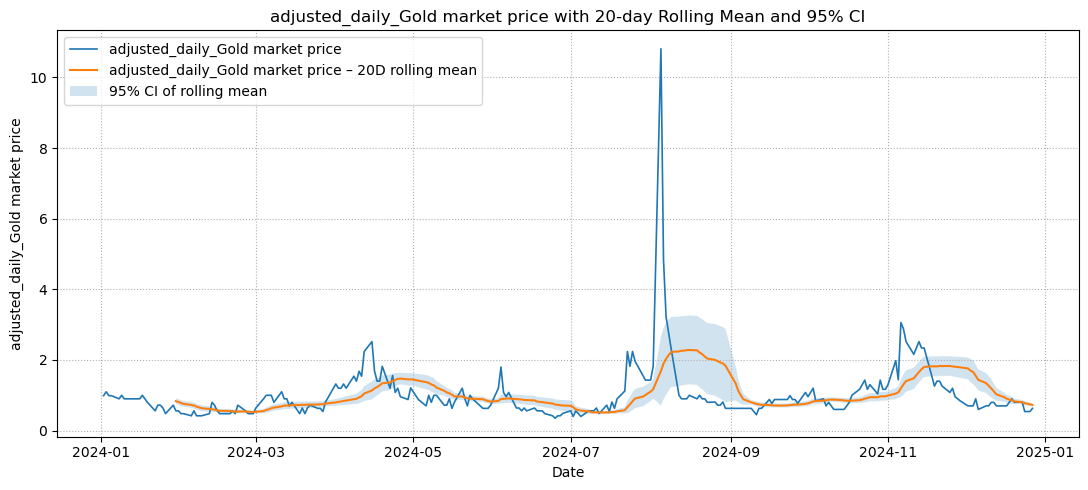

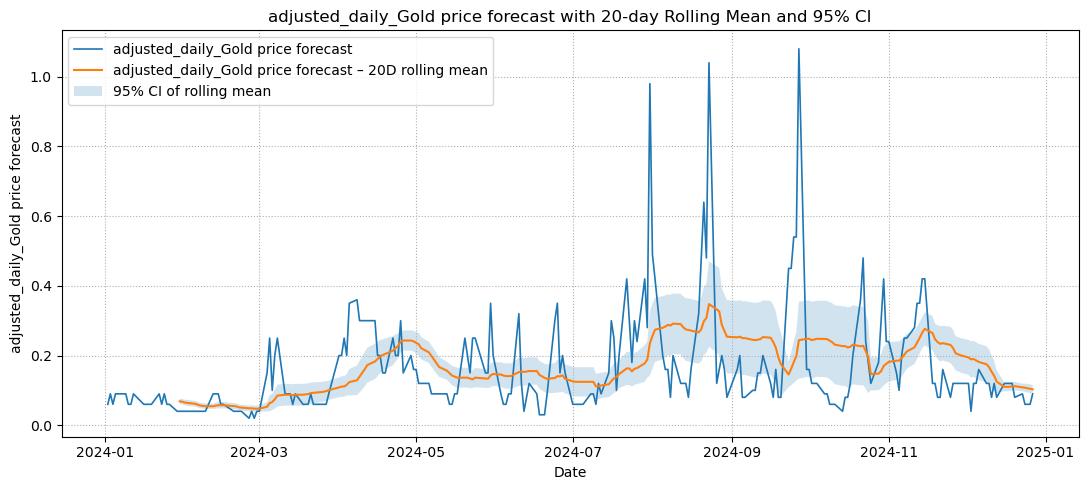

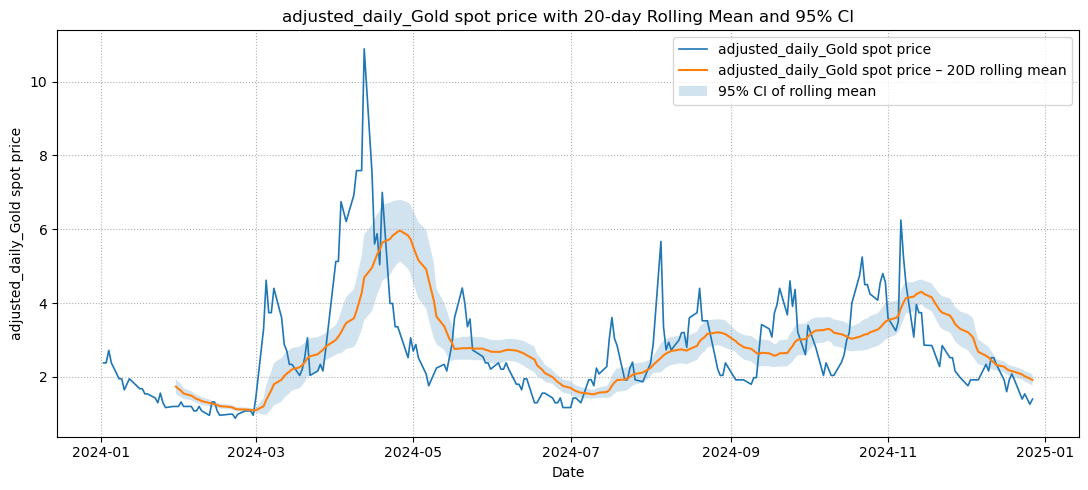

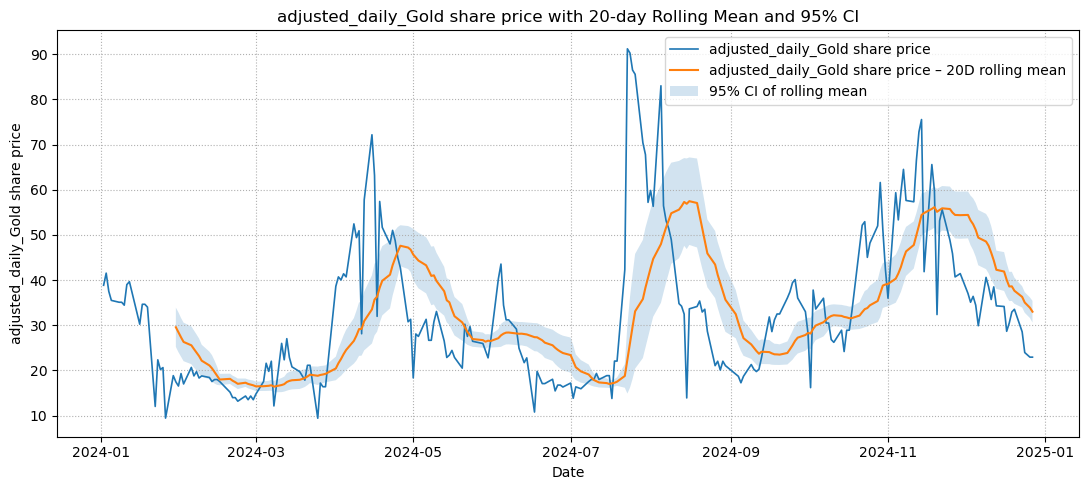

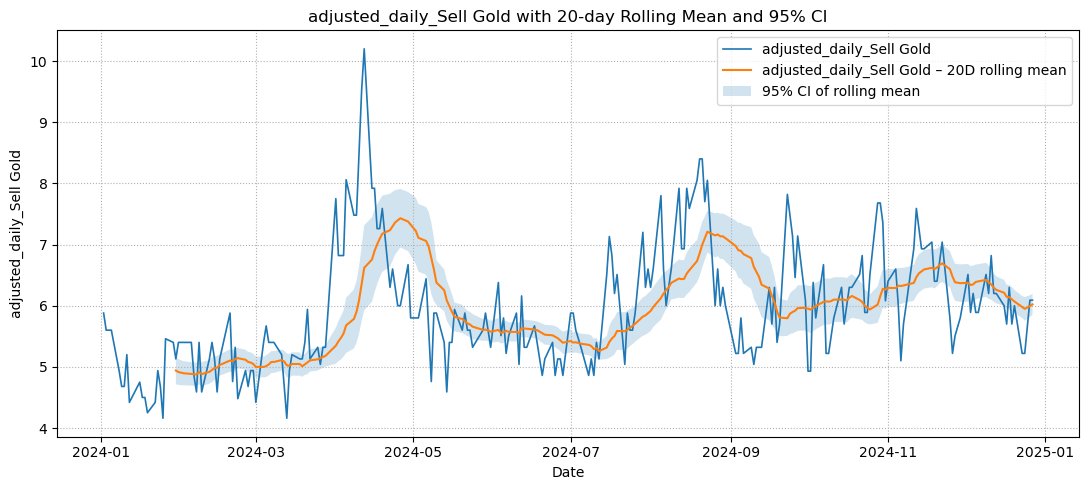

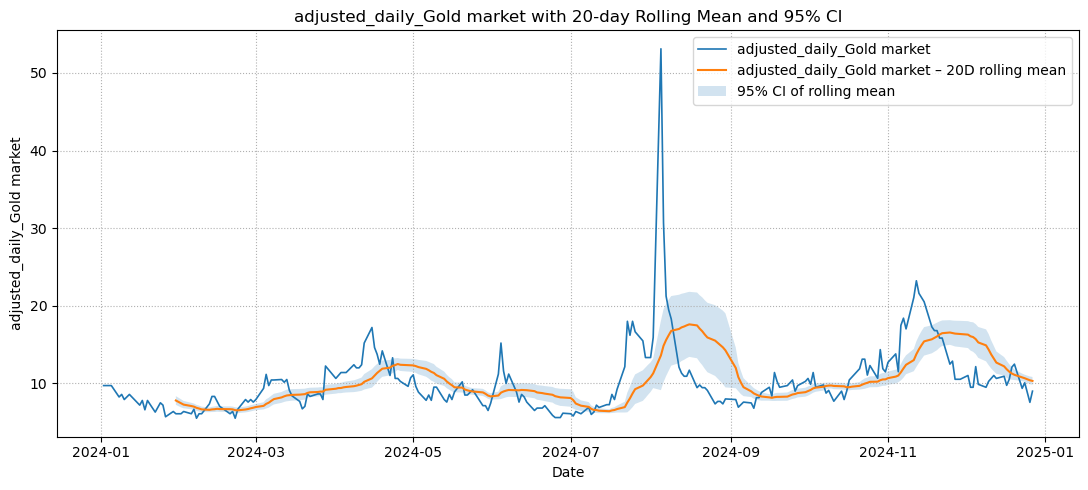

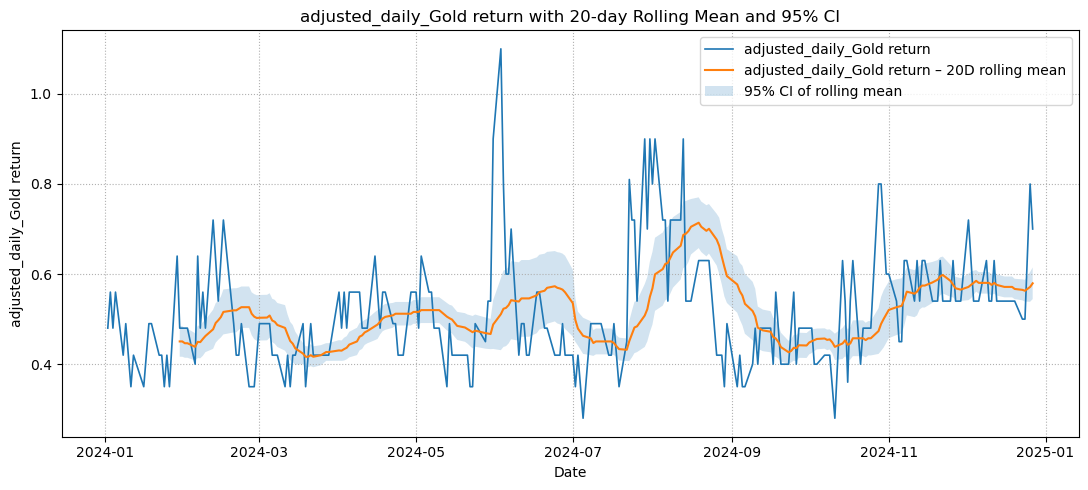

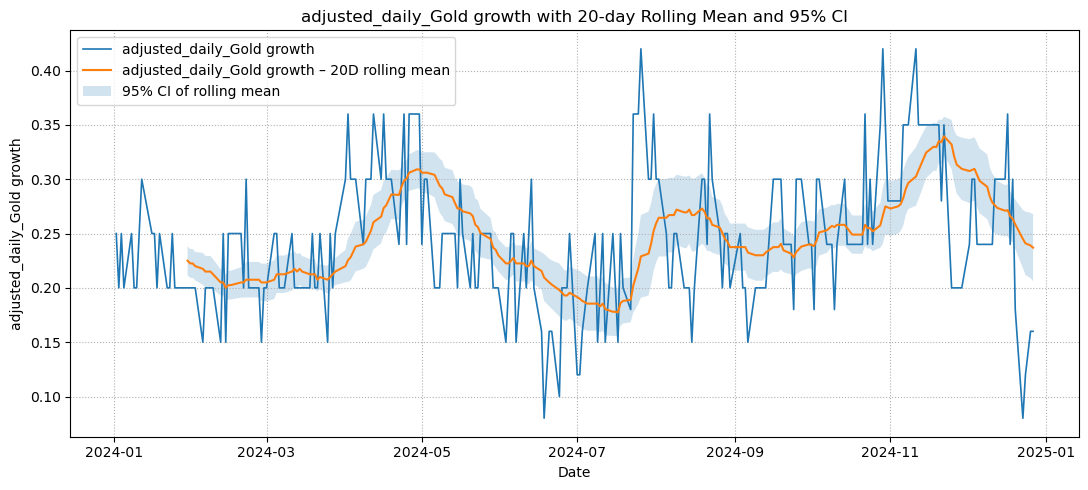

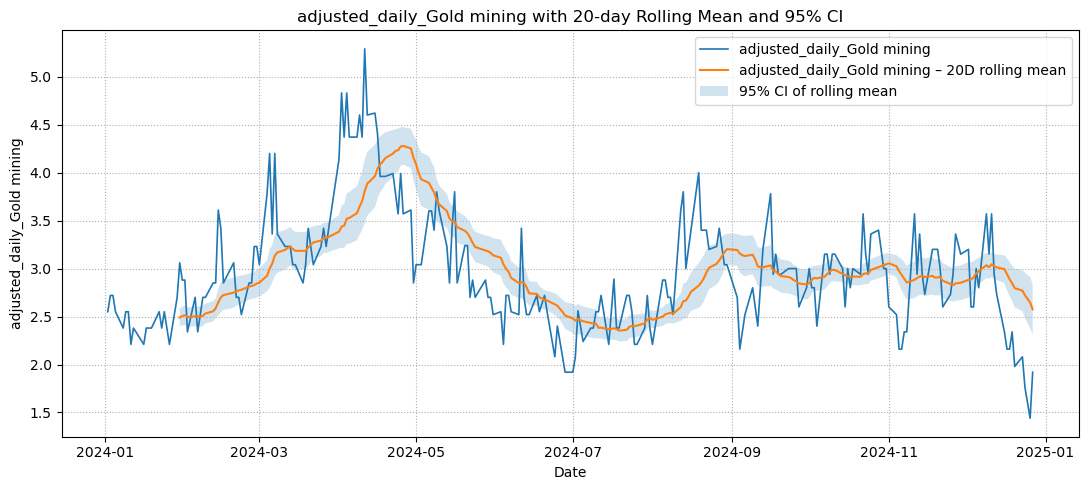

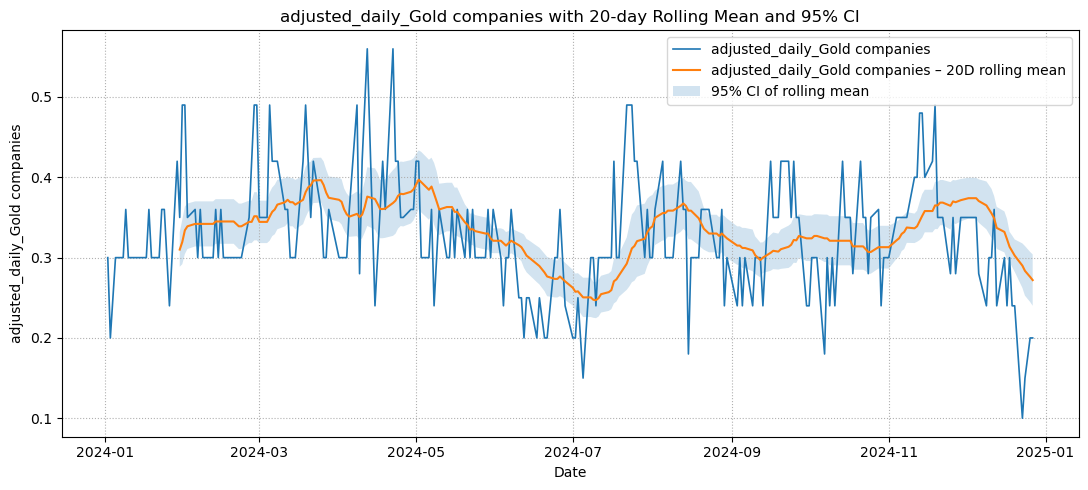

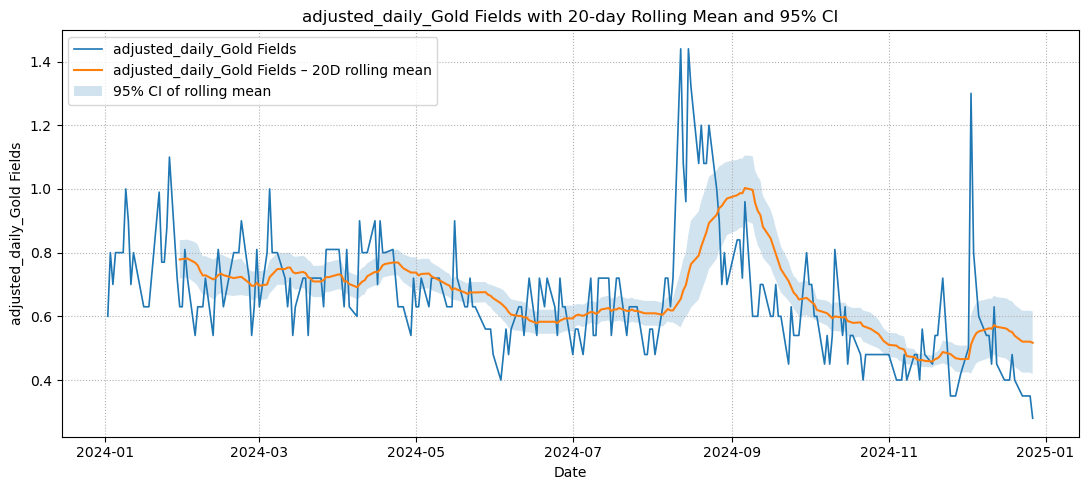

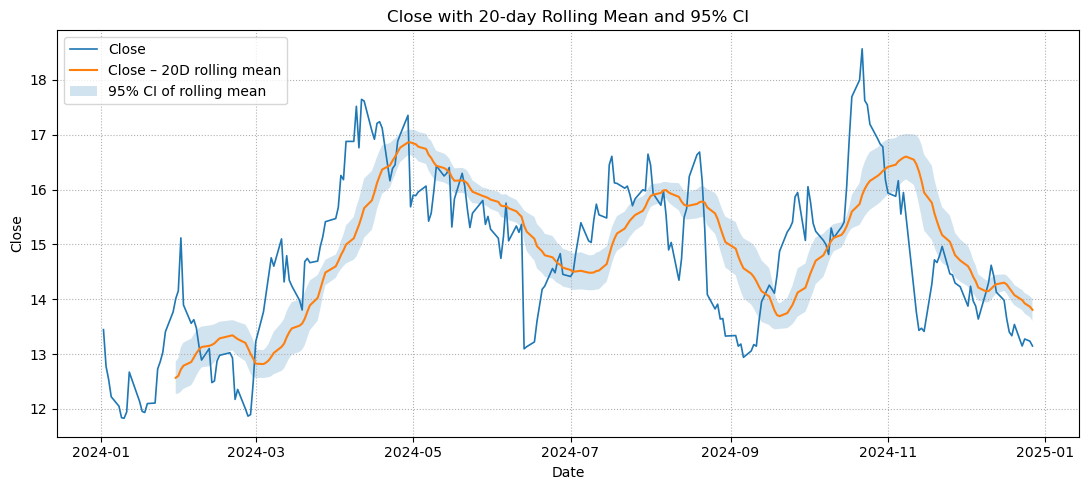

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Settings
# =========================
DATE_COL = "Date"     # required in your df
WINDOW   = 20         # rolling window (days)
Z        = 1.96       # ~95% CI
SAVE_PNG = False      # set True to save each plot as PNG
OUT_DIR  = "plots"    # folder to save into if SAVE_PNG=True

# =========================
# Helpers
# =========================
def rolling_ci(series: pd.Series, window=20, z=1.96):
    """
    Rolling mean ± z * (std / sqrt(window)).
    Interpreted as a 95% CI for the *rolling mean* over the chosen window.
    """
    mean = series.rolling(window).mean()
    std  = series.rolling(window).std()     # sample std (ddof=1 by default)
    se   = std / np.sqrt(window)
    lower = mean - z * se
    upper = mean + z * se
    return mean, lower, upper

def prep_df(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    if date_col not in df.columns:
        raise ValueError(f"'{date_col}' must be a column in df.")
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out.dropna(subset=[date_col]).sort_values(date_col).set_index(date_col)
    # keep only numerics for plotting; coerce non-numeric to NaN
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

# =========================
# Build plots
# =========================
# Use your existing df
df_ts = prep_df(df, DATE_COL)

# Choose all numeric columns (everything except Date since it's the index now)
cols_to_plot = df_ts.columns.tolist()

# (optional) ensure save dir
if SAVE_PNG:
    import os
    os.makedirs(OUT_DIR, exist_ok=True)

for col in cols_to_plot:
    s = df_ts[col].dropna()
    if s.empty:
        print(f"Skipping '{col}' (no data).")
        continue

    m, lo, hi = rolling_ci(s, window=WINDOW, z=Z)

    plt.figure(figsize=(11, 5))
    plt.plot(s.index, s.values, label=col, linewidth=1.2)
    plt.plot(m.index, m.values, label=f"{col} – {WINDOW}D rolling mean", linewidth=1.5)
    # CI may have NaNs at the start (until window fills)
    plt.fill_between(lo.index, lo.values, hi.values, alpha=0.2, label="95% CI of rolling mean")

    plt.title(f"{col} with {WINDOW}-day Rolling Mean and 95% CI")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()

    if SAVE_PNG:
        safe_col = "".join(ch if ch.isalnum() or ch in "-_." else "_" for ch in col)
        plt.savefig(f"{OUT_DIR}/{safe_col}.png", dpi=130)
    plt.show()


### Lead–Lag Analysis:Cross-correlation

We will model returns for the lead lag relationship

In [88]:
target_col = 'Close'

# 1) Clean & order dates
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date')

# 2) Identify numeric cols
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col not in num_cols:
    raise ValueError(f"{target_col} must be numeric.")
other_cols = [c for c in num_cols if c != target_col]

# 3) Compute returns on numeric slice (keeps Date by reattaching)
num_ret = (df[[target_col] + other_cols]
           .pct_change()
           .replace([np.inf, -np.inf], np.nan))

# 4) Rebuild df with Date + returns, dropping rows where all numerics are NaN
df = pd.concat([df[['Date']], num_ret], axis=1)
df = df.dropna(subset=[target_col] + other_cols, how='all').reset_index(drop=True)


In [89]:
df

,Date,Close,adjusted_daily_Buy Gold,adjusted_daily_Gold price per ounce,adjusted_daily_Gold futures price,adjusted_daily_Gold market price,adjusted_daily_Gold price forecast,adjusted_daily_Gold spot price,adjusted_daily_Gold share price,adjusted_daily_Sell Gold,adjusted_daily_Gold market,adjusted_daily_Gold return,adjusted_daily_Gold growth,adjusted_daily_Gold mining,adjusted_daily_Gold companies,adjusted_daily_Gold Fields
0,2024-01-03,-0.049787,-0.112903,0.000000,0.00,0.111111,0.500000,0.000000,0.068966,-0.047619,0.000000,0.166667,-0.200000,0.066667,-3.333333e-01,0.333333
1,2024-01-04,-0.018713,0.000000,0.100000,0.00,-0.100000,-0.333333,0.142857,-0.096774,0.000000,0.000000,-0.142857,0.250000,0.000000,2.500000e-01,-0.125000
2,2024-01-05,-0.025172,0.072727,-0.090909,0.00,0.000000,0.500000,-0.125000,-0.053571,0.000000,0.000000,0.166667,-0.200000,-0.062500,2.000000e-01,0.142857
3,2024-01-08,-0.014084,-0.116761,-0.175000,0.00,-0.090909,0.000000,-0.180672,-0.011546,-0.117857,-0.151235,-0.250000,0.250000,-0.066667,-2.220446e-16,0.000000
4,2024-01-09,-0.017460,-0.196429,0.111111,0.00,0.111111,0.000000,0.000000,0.000000,-0.052632,0.040000,0.166667,-0.200000,0.071429,2.000000e-01,0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,2024-12-20,0.015464,-0.125000,-0.300000,-0.25,-0.111111,-0.333333,-0.076923,0.018519,0.052632,0.032258,0.000000,-0.400000,-0.153846,0.000000e+00,-0.166667
245,2024-12-23,-0.029007,0.025000,-0.083333,-0.50,0.012500,0.125000,-0.270833,-0.148733,-0.130000,-0.250000,-0.074074,-0.555556,0.050505,-5.833333e-01,-0.125000
246,2024-12-24,0.009709,0.000000,0.000000,0.00,-0.333333,-0.333333,0.100000,-0.160714,0.000000,0.076923,0.000000,0.500000,-0.153846,5.000000e-01,0.000000
247,2024-12-26,-0.002959,0.163265,0.142857,0.00,0.000000,0.000000,-0.181818,-0.042553,0.166667,-0.250000,0.600000,0.333333,-0.181818,3.333333e-01,0.000000



=== Cross-Correlation: Close vs adjusted_daily_Buy Gold ===
    Lag  Correlation
0   -20     0.111824
1   -19     0.026089
2   -18    -0.082911
3   -17     0.030433
4   -16    -0.072682
5   -15     0.024534
6   -14    -0.009708
7   -13    -0.120415
8   -12     0.055248
9   -11    -0.064303
10  -10     0.050057
11   -9    -0.017734
12   -8     0.049219
13   -7     0.172373
14   -6    -0.098452
15   -5     0.069553
16   -4     0.062296
17   -3     0.053590
18   -2     0.038472
19   -1     0.103577
20    0     0.086170
21    1     0.069583
22    2    -0.045624
23    3     0.031164
24    4    -0.051251
25    5     0.030782
26    6    -0.015042
27    7    -0.015949
28    8     0.018165
29    9    -0.160573
30   10    -0.102392
31   11     0.040273
32   12    -0.094384
33   13    -0.028558
34   14     0.041457
35   15    -0.067739
36   16    -0.005041
37   17    -0.057708
38   18     0.148060
39   19     0.040031
40   20    -0.032707

Top 5 absolute correlations:
    Lag  Correlation
13   -

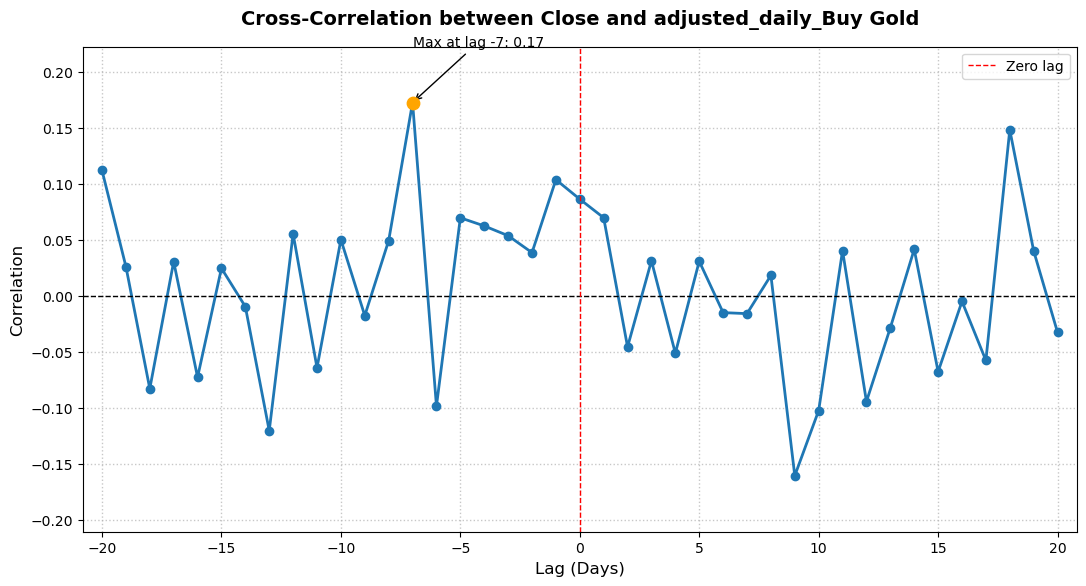


=== Cross-Correlation: Close vs adjusted_daily_Gold price per ounce ===
    Lag  Correlation
0   -20    -0.116782
1   -19     0.006457
2   -18     0.034624
3   -17    -0.008344
4   -16     0.014399
5   -15     0.012333
6   -14     0.031145
7   -13     0.052397
8   -12    -0.016337
9   -11     0.016733
10  -10    -0.066246
11   -9    -0.081453
12   -8     0.070031
13   -7    -0.073892
14   -6     0.016455
15   -5    -0.021329
16   -4     0.008109
17   -3     0.097971
18   -2     0.027458
19   -1     0.133693
20    0     0.078940
21    1     0.066195
22    2     0.004456
23    3     0.021278
24    4    -0.066300
25    5    -0.027031
26    6     0.044361
27    7    -0.056321
28    8     0.038834
29    9     0.089390
30   10    -0.133420
31   11     0.049867
32   12     0.009660
33   13    -0.105449
34   14    -0.113512
35   15    -0.009797
36   16    -0.004690
37   17    -0.188174
38   18     0.209947
39   19    -0.085916
40   20     0.052089

Top 5 absolute correlations:
    Lag  Correl

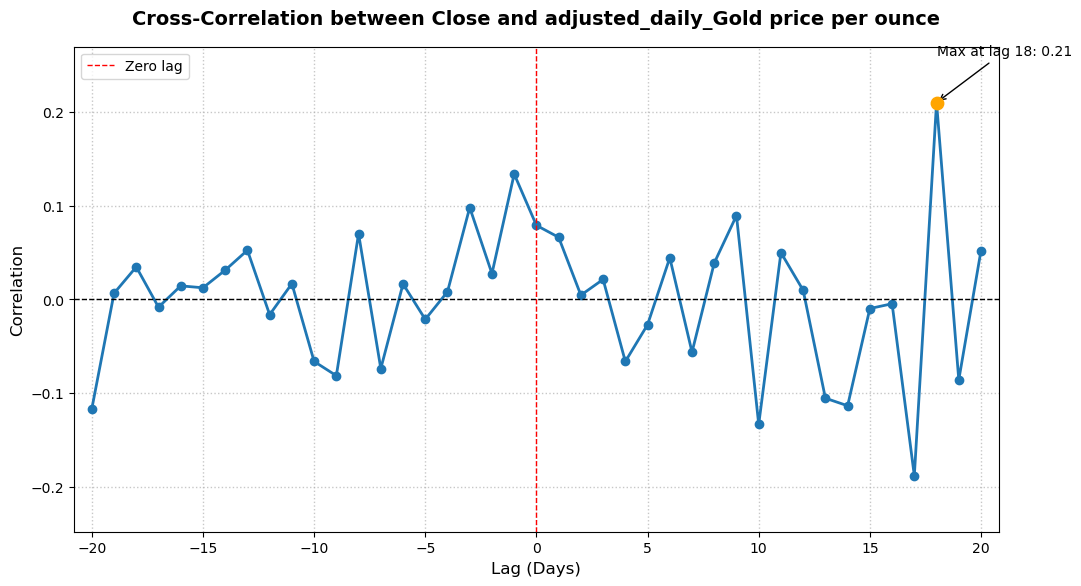


=== Cross-Correlation: Close vs adjusted_daily_Gold futures price ===
    Lag  Correlation
0   -20    -0.117032
1   -19     0.089104
2   -18    -0.119802
3   -17     0.106721
4   -16     0.003708
5   -15     0.039793
6   -14    -0.123840
7   -13     0.055094
8   -12     0.074138
9   -11    -0.019546
10  -10    -0.041071
11   -9    -0.011060
12   -8     0.062733
13   -7    -0.076781
14   -6     0.101497
15   -5    -0.000345
16   -4     0.047365
17   -3    -0.000657
18   -2     0.129242
19   -1    -0.020102
20    0     0.059023
21    1     0.084025
22    2    -0.034338
23    3     0.038163
24    4     0.026379
25    5    -0.117622
26    6     0.006343
27    7     0.050836
28    8     0.018926
29    9    -0.012055
30   10    -0.029981
31   11     0.126048
32   12    -0.065088
33   13    -0.030354
34   14    -0.059214
35   15    -0.057629
36   16     0.033099
37   17    -0.087623
38   18     0.164928
39   19    -0.074168
40   20     0.020381

Top 5 absolute correlations:
    Lag  Correlat

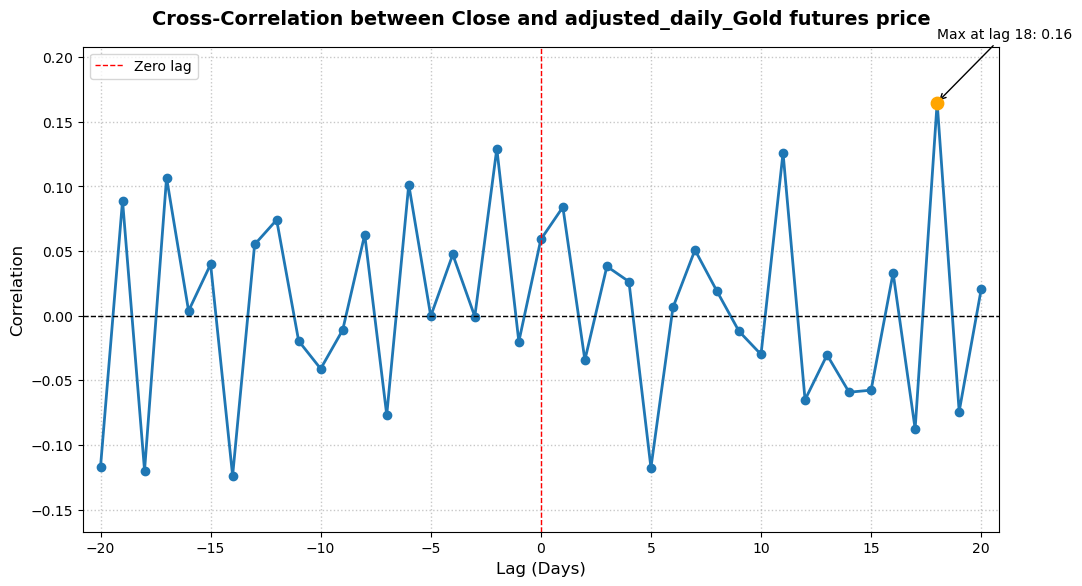


=== Cross-Correlation: Close vs adjusted_daily_Gold market price ===
    Lag  Correlation
0   -20    -0.026742
1   -19    -0.003790
2   -18     0.020615
3   -17     0.025494
4   -16     0.025127
5   -15    -0.013456
6   -14     0.136068
7   -13     0.024905
8   -12     0.019094
9   -11    -0.008174
10  -10    -0.007269
11   -9     0.003809
12   -8    -0.021458
13   -7    -0.063377
14   -6     0.064768
15   -5     0.010614
16   -4     0.031312
17   -3     0.098181
18   -2     0.014723
19   -1     0.008365
20    0    -0.043939
21    1     0.075696
22    2    -0.046664
23    3    -0.062406
24    4     0.015397
25    5    -0.140533
26    6     0.041499
27    7     0.046087
28    8     0.001798
29    9     0.063274
30   10     0.028393
31   11     0.059587
32   12    -0.036325
33   13    -0.037118
34   14    -0.152473
35   15    -0.100485
36   16     0.044194
37   17    -0.115198
38   18     0.084552
39   19    -0.040701
40   20     0.040381

Top 5 absolute correlations:
    Lag  Correlati

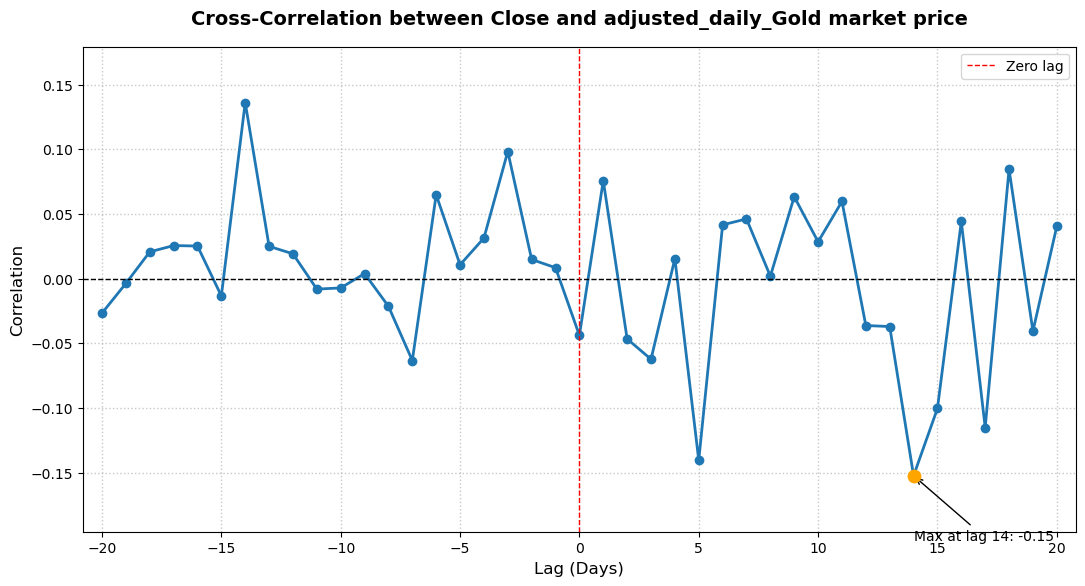


=== Cross-Correlation: Close vs adjusted_daily_Gold price forecast ===
    Lag  Correlation
0   -20    -0.120023
1   -19     0.002042
2   -18     0.048807
3   -17     0.005002
4   -16    -0.120273
5   -15    -0.020365
6   -14     0.007114
7   -13    -0.026966
8   -12    -0.029059
9   -11     0.048521
10  -10     0.056593
11   -9    -0.105484
12   -8    -0.021750
13   -7     0.086533
14   -6    -0.076573
15   -5    -0.104419
16   -4     0.003438
17   -3     0.100821
18   -2     0.102148
19   -1     0.086050
20    0     0.121101
21    1    -0.007855
22    2     0.081048
23    3    -0.100117
24    4     0.064457
25    5    -0.091743
26    6    -0.008114
27    7     0.023194
28    8    -0.054299
29    9    -0.004613
30   10    -0.230635
31   11     0.021632
32   12     0.125425
33   13     0.014524
34   14     0.048338
35   15    -0.013911
36   16     0.045710
37   17     0.014840
38   18     0.043541
39   19    -0.011744
40   20     0.102977

Top 5 absolute correlations:
    Lag  Correla

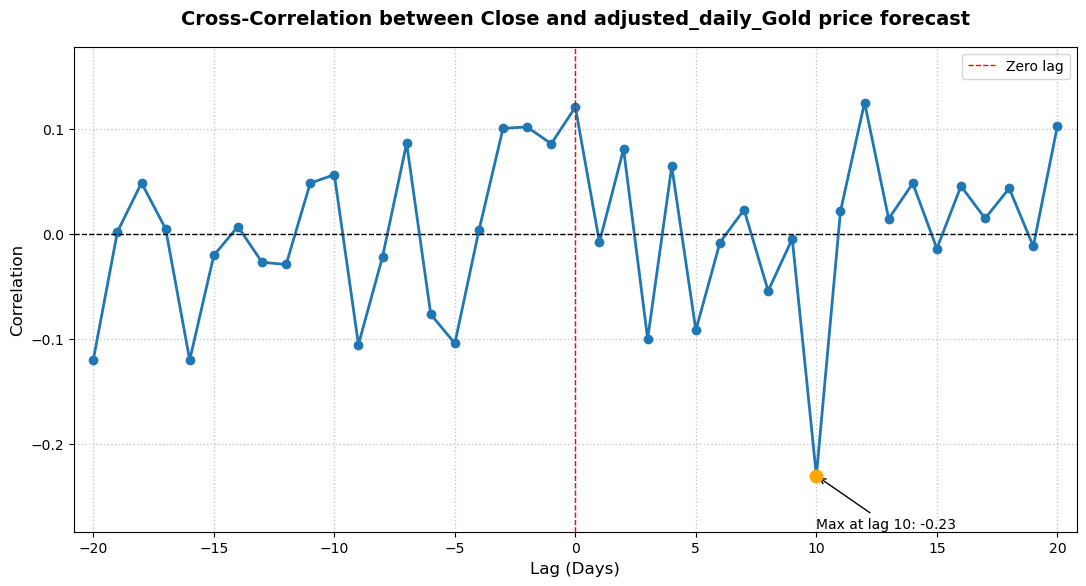


=== Cross-Correlation: Close vs adjusted_daily_Gold spot price ===
    Lag  Correlation
0   -20    -0.099410
1   -19    -0.042263
2   -18     0.011535
3   -17     0.049896
4   -16    -0.046918
5   -15    -0.029046
6   -14     0.012988
7   -13     0.046269
8   -12    -0.015815
9   -11    -0.024770
10  -10     0.028181
11   -9    -0.052353
12   -8    -0.060064
13   -7    -0.096797
14   -6     0.011417
15   -5     0.013377
16   -4    -0.061197
17   -3     0.101199
18   -2     0.113423
19   -1     0.154610
20    0     0.180850
21    1     0.102971
22    2     0.086890
23    3    -0.037509
24    4     0.052720
25    5    -0.056807
26    6     0.050822
27    7    -0.077437
28    8    -0.008959
29    9    -0.004382
30   10    -0.039169
31   11     0.004853
32   12     0.053902
33   13     0.015225
34   14    -0.095909
35   15    -0.098558
36   16    -0.033425
37   17    -0.094524
38   18     0.070033
39   19    -0.102409
40   20     0.054730

Top 5 absolute correlations:
    Lag  Correlation

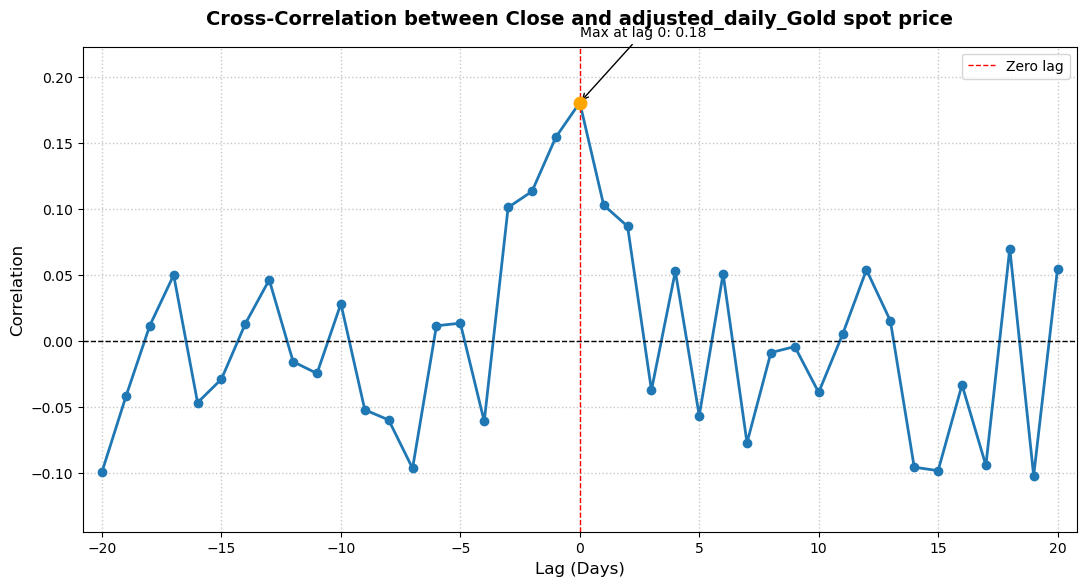


=== Cross-Correlation: Close vs adjusted_daily_Gold share price ===
    Lag  Correlation
0   -20     0.060436
1   -19     0.033454
2   -18    -0.069409
3   -17     0.070302
4   -16     0.031628
5   -15    -0.035407
6   -14     0.033256
7   -13    -0.024193
8   -12     0.037278
9   -11     0.013560
10  -10    -0.080335
11   -9     0.062101
12   -8    -0.068514
13   -7     0.098699
14   -6    -0.011305
15   -5     0.075811
16   -4     0.078254
17   -3    -0.049564
18   -2     0.148542
19   -1     0.041337
20    0     0.111269
21    1     0.003916
22    2    -0.025794
23    3     0.051763
24    4    -0.045718
25    5    -0.074395
26    6     0.023486
27    7     0.096326
28    8    -0.168685
29    9     0.050626
30   10    -0.032387
31   11     0.097654
32   12    -0.142728
33   13     0.041553
34   14    -0.091016
35   15    -0.079726
36   16     0.034935
37   17    -0.057864
38   18     0.171914
39   19     0.058931
40   20     0.031227

Top 5 absolute correlations:
    Lag  Correlatio

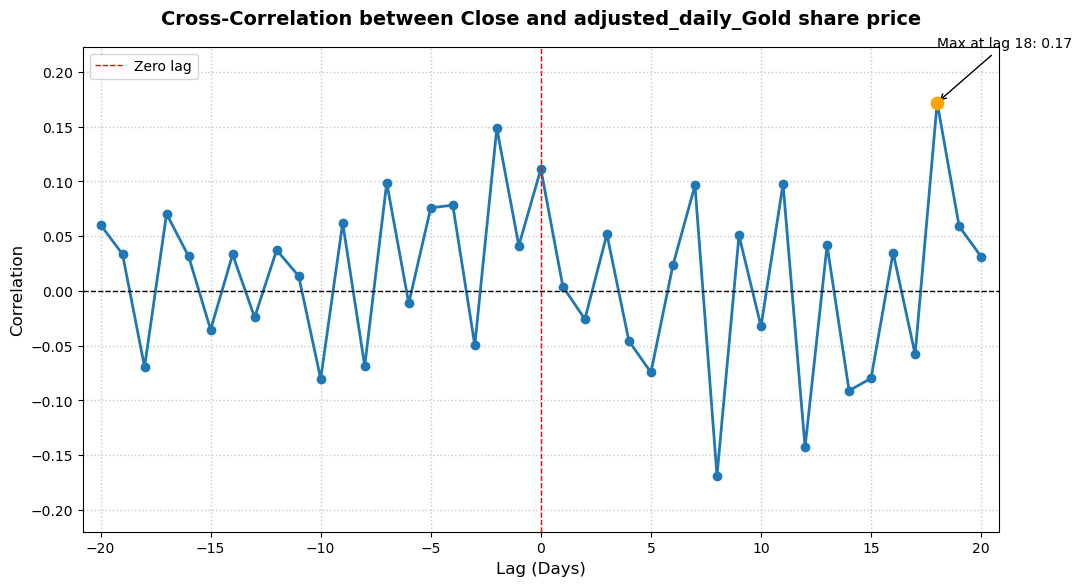


=== Cross-Correlation: Close vs adjusted_daily_Sell Gold ===
    Lag  Correlation
0   -20    -0.090526
1   -19    -0.002784
2   -18     0.036088
3   -17    -0.015071
4   -16     0.034794
5   -15    -0.040110
6   -14     0.145670
7   -13    -0.176664
8   -12     0.085886
9   -11    -0.093967
10  -10     0.003414
11   -9     0.056116
12   -8    -0.065927
13   -7     0.039861
14   -6     0.015204
15   -5     0.011928
16   -4     0.010960
17   -3    -0.013749
18   -2     0.060335
19   -1     0.060698
20    0     0.107912
21    1    -0.035694
22    2     0.075857
23    3     0.023953
24    4     0.060791
25    5    -0.045823
26    6     0.072029
27    7     0.026559
28    8    -0.095957
29    9    -0.068599
30   10    -0.037724
31   11     0.001751
32   12     0.038843
33   13    -0.101132
34   14    -0.017299
35   15     0.000778
36   16     0.014537
37   17    -0.073198
38   18    -0.039200
39   19     0.060843
40   20    -0.111529

Top 5 absolute correlations:
    Lag  Correlation
7   -

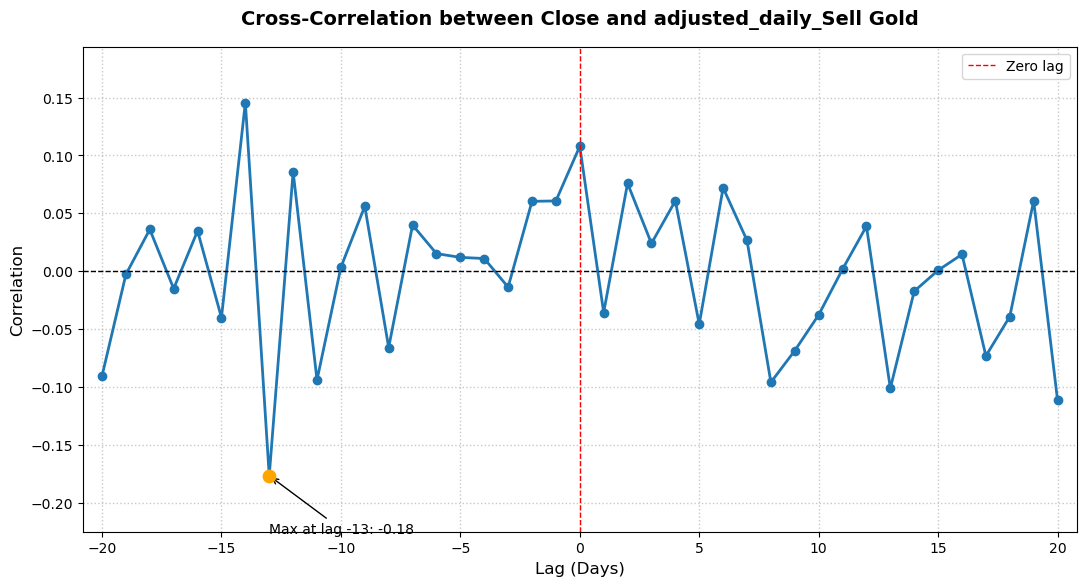


=== Cross-Correlation: Close vs adjusted_daily_Gold market ===
    Lag  Correlation
0   -20    -0.011651
1   -19    -0.011734
2   -18     0.020444
3   -17     0.025497
4   -16     0.059029
5   -15     0.044118
6   -14     0.074332
7   -13     0.053099
8   -12    -0.033388
9   -11     0.006243
10  -10    -0.039347
11   -9     0.028324
12   -8     0.008735
13   -7    -0.098383
14   -6     0.058554
15   -5     0.029441
16   -4     0.026678
17   -3     0.052972
18   -2     0.072132
19   -1    -0.025522
20    0    -0.010638
21    1     0.007188
22    2     0.002153
23    3    -0.037830
24    4     0.021077
25    5    -0.106976
26    6     0.061633
27    7     0.044838
28    8    -0.045598
29    9     0.076999
30   10     0.014918
31   11     0.029726
32   12    -0.010765
33   13    -0.060339
34   14    -0.135604
35   15    -0.063157
36   16     0.001801
37   17    -0.077455
38   18     0.097381
39   19    -0.029108
40   20    -0.004565

Top 5 absolute correlations:
    Lag  Correlation
34 

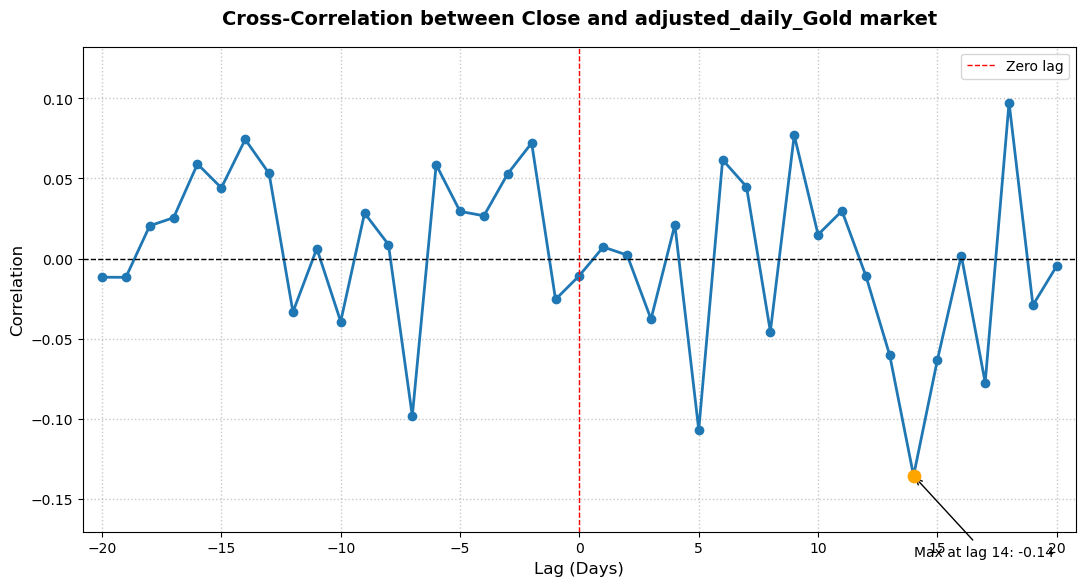


=== Cross-Correlation: Close vs adjusted_daily_Gold return ===
    Lag  Correlation
0   -20     0.100957
1   -19    -0.009830
2   -18     0.014893
3   -17    -0.111821
4   -16     0.111502
5   -15    -0.074014
6   -14     0.011412
7   -13    -0.088343
8   -12     0.206875
9   -11    -0.046012
10  -10    -0.065835
11   -9     0.069855
12   -8     0.054749
13   -7    -0.010283
14   -6    -0.043349
15   -5    -0.005158
16   -4     0.089412
17   -3    -0.009263
18   -2    -0.029817
19   -1     0.028859
20    0     0.055671
21    1    -0.050365
22    2    -0.002638
23    3     0.116666
24    4     0.000657
25    5    -0.019767
26    6     0.135928
27    7    -0.078442
28    8    -0.018863
29    9    -0.101123
30   10    -0.084131
31   11    -0.109894
32   12    -0.000697
33   13    -0.037863
34   14    -0.019598
35   15     0.127783
36   16     0.091458
37   17    -0.095494
38   18     0.075329
39   19    -0.002137
40   20    -0.113568

Top 5 absolute correlations:
    Lag  Correlation
8  

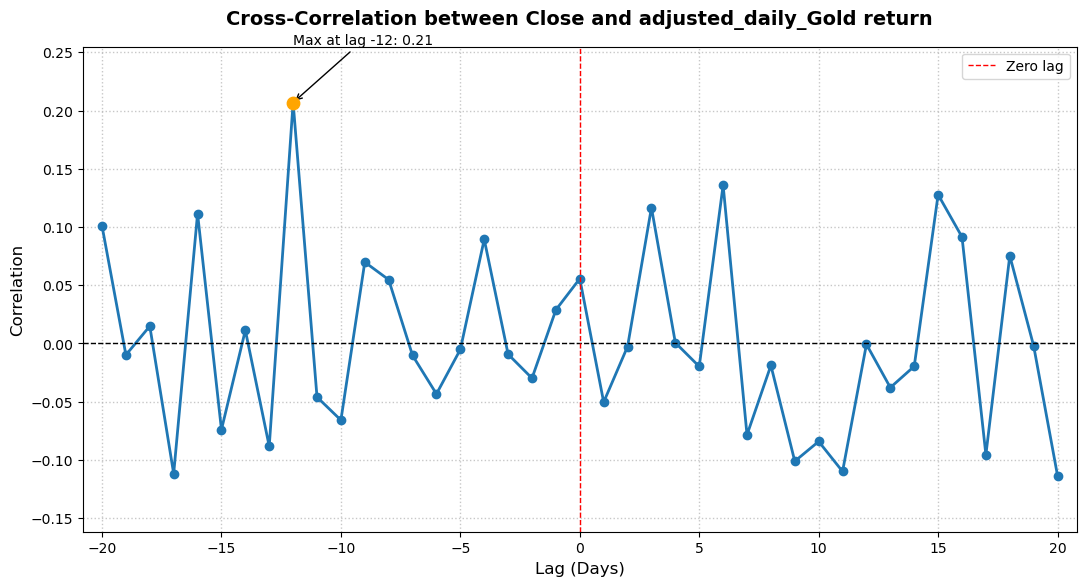


=== Cross-Correlation: Close vs adjusted_daily_Gold growth ===
    Lag  Correlation
0   -20     0.028588
1   -19     0.026785
2   -18    -0.055203
3   -17     0.088043
4   -16     0.002228
5   -15     0.025233
6   -14    -0.002059
7   -13    -0.033706
8   -12    -0.024237
9   -11     0.094973
10  -10     0.012434
11   -9     0.030630
12   -8    -0.011934
13   -7    -0.114106
14   -6     0.025595
15   -5     0.001257
16   -4    -0.010585
17   -3     0.018383
18   -2     0.082545
19   -1     0.063072
20    0     0.049253
21    1     0.015551
22    2    -0.050931
23    3    -0.128664
24    4     0.094707
25    5    -0.040386
26    6    -0.003823
27    7     0.054736
28    8    -0.038787
29    9     0.097493
30   10    -0.083144
31   11     0.023950
32   12     0.014380
33   13     0.001100
34   14    -0.023470
35   15    -0.023084
36   16     0.090071
37   17     0.002616
38   18     0.047282
39   19     0.053900
40   20    -0.090884

Top 5 absolute correlations:
    Lag  Correlation
23 

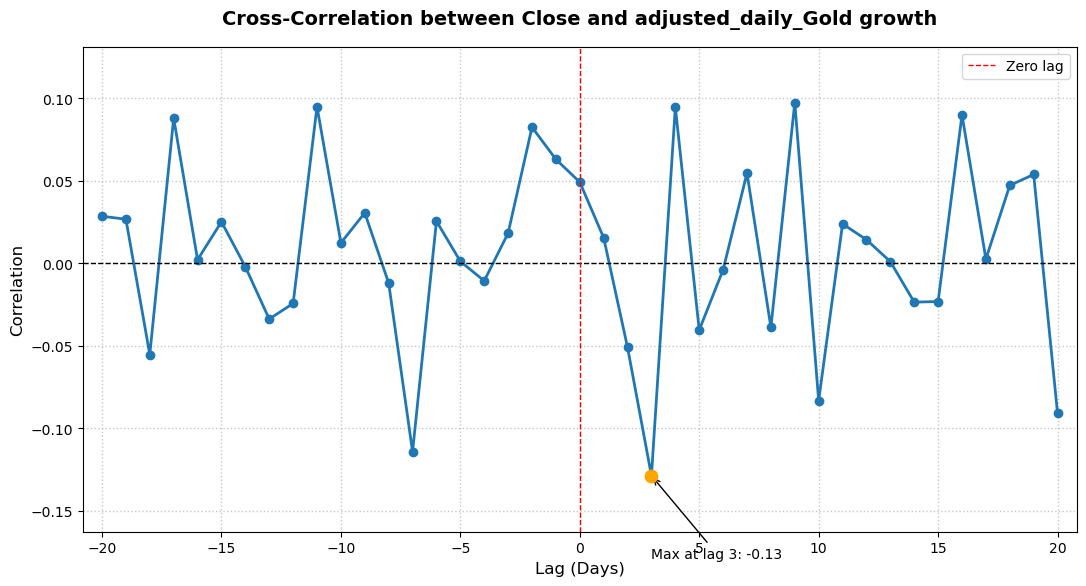


=== Cross-Correlation: Close vs adjusted_daily_Gold mining ===
    Lag  Correlation
0   -20     0.040123
1   -19    -0.002958
2   -18     0.094632
3   -17    -0.046833
4   -16     0.004812
5   -15     0.022024
6   -14     0.011739
7   -13    -0.048829
8   -12    -0.012948
9   -11    -0.047593
10  -10    -0.067425
11   -9     0.008431
12   -8     0.023973
13   -7    -0.021065
14   -6     0.035456
15   -5    -0.089683
16   -4     0.143547
17   -3    -0.087259
18   -2    -0.001337
19   -1    -0.020009
20    0     0.082574
21    1     0.112212
22    2    -0.008376
23    3     0.039073
24    4    -0.015249
25    5     0.064956
26    6     0.040125
27    7     0.041282
28    8    -0.072008
29    9     0.017182
30   10    -0.039533
31   11     0.010632
32   12    -0.052054
33   13    -0.052564
34   14    -0.048066
35   15    -0.015912
36   16    -0.003175
37   17    -0.010593
38   18    -0.053352
39   19     0.029148
40   20     0.032155

Top 5 absolute correlations:
    Lag  Correlation
16 

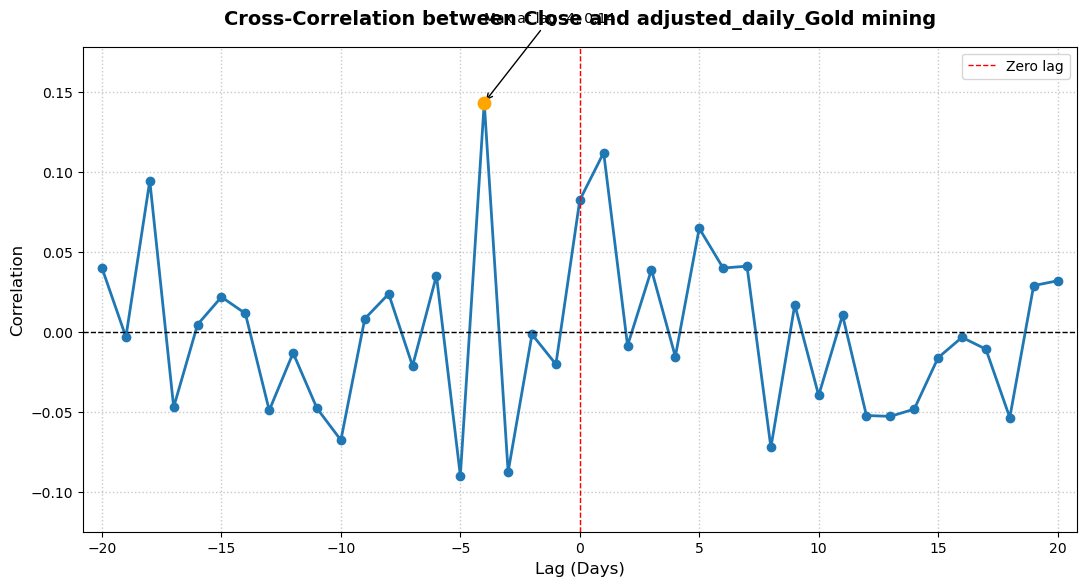


=== Cross-Correlation: Close vs adjusted_daily_Gold companies ===
    Lag  Correlation
0   -20    -0.011533
1   -19     0.018852
2   -18     0.072847
3   -17    -0.046339
4   -16     0.009823
5   -15    -0.163748
6   -14     0.051670
7   -13    -0.027882
8   -12     0.078065
9   -11     0.077124
10  -10    -0.049815
11   -9     0.089367
12   -8    -0.112828
13   -7     0.045061
14   -6    -0.086337
15   -5    -0.004135
16   -4     0.018729
17   -3     0.064058
18   -2    -0.026069
19   -1     0.070695
20    0    -0.038903
21    1     0.063559
22    2    -0.044760
23    3     0.125627
24    4    -0.029863
25    5    -0.014999
26    6     0.095431
27    7     0.001214
28    8    -0.030219
29    9    -0.060470
30   10    -0.026288
31   11     0.070435
32   12    -0.102983
33   13     0.048789
34   14    -0.077089
35   15    -0.012030
36   16    -0.039075
37   17     0.033443
38   18    -0.004600
39   19    -0.031209
40   20     0.004545

Top 5 absolute correlations:
    Lag  Correlation


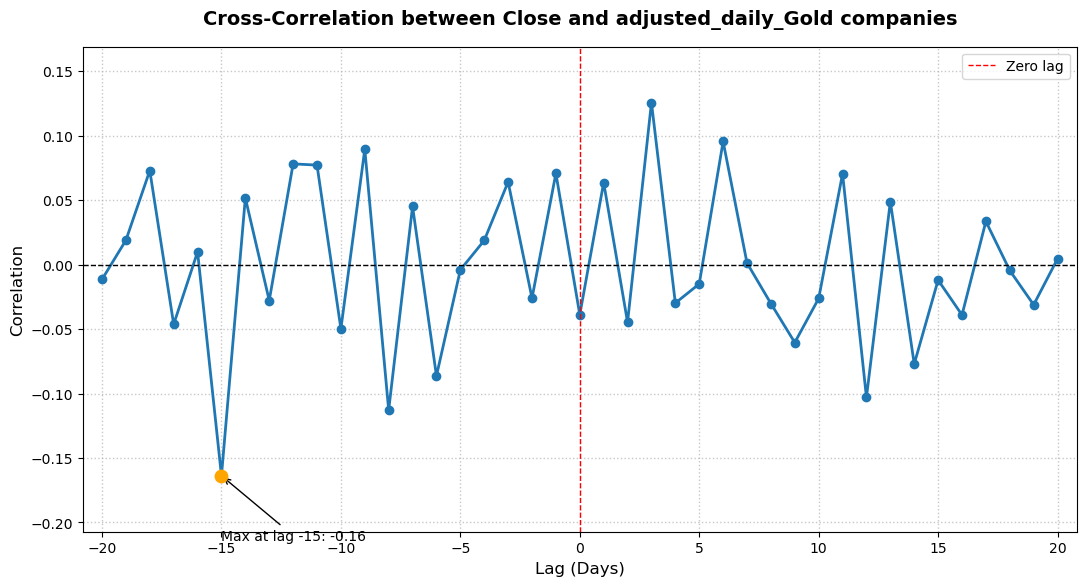


=== Cross-Correlation: Close vs adjusted_daily_Gold Fields ===
    Lag  Correlation
0   -20    -0.056087
1   -19     0.127824
2   -18    -0.054209
3   -17     0.021714
4   -16    -0.042290
5   -15    -0.060002
6   -14    -0.029097
7   -13     0.010019
8   -12    -0.078576
9   -11    -0.001459
10  -10     0.145839
11   -9     0.006909
12   -8     0.005314
13   -7    -0.043806
14   -6     0.018778
15   -5    -0.054604
16   -4    -0.007799
17   -3    -0.075864
18   -2     0.047428
19   -1     0.049318
20    0    -0.099941
21    1     0.045016
22    2     0.064203
23    3    -0.015266
24    4     0.036398
25    5     0.036064
26    6     0.056438
27    7     0.007053
28    8    -0.010857
29    9    -0.104922
30   10    -0.024548
31   11    -0.053306
32   12    -0.048405
33   13     0.051392
34   14     0.024058
35   15    -0.031332
36   16    -0.004810
37   17    -0.007004
38   18     0.026802
39   19    -0.075812
40   20     0.105210

Top 5 absolute correlations:
    Lag  Correlation
10 

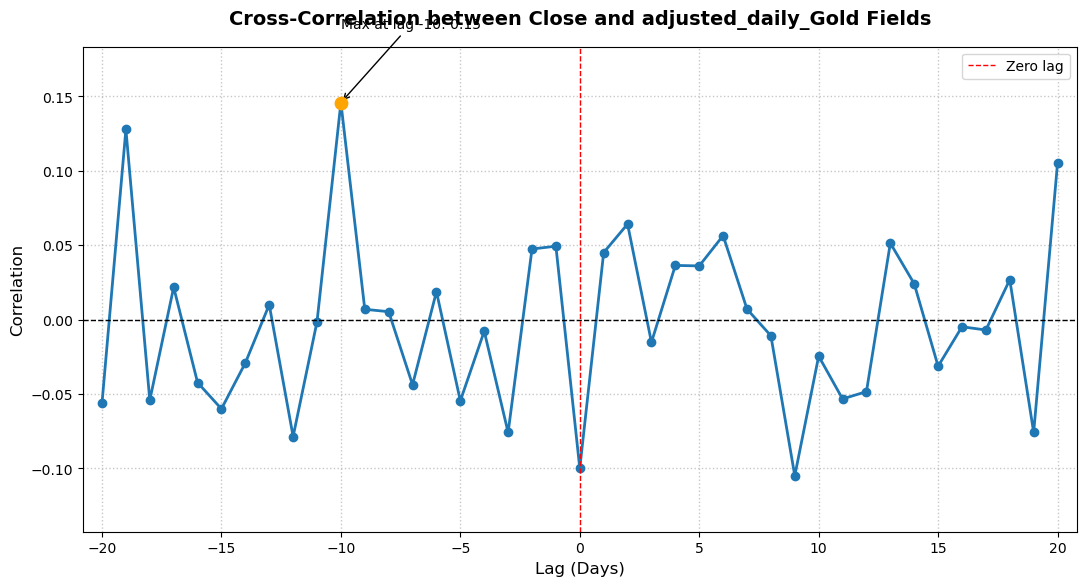

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Parameters
lags = np.arange(-20, 21)
target_col = 'Close'

# Loop through each column except 'Date' and target_col
for col in [c for c in df.columns if c not in ['Date', target_col]]:
    print(f"\n=== Cross-Correlation: {target_col} vs {col} ===")

    # compute correlations
    cross_corr = [df[target_col].corr(df[col].shift(lag)) for lag in lags]

    # create a DataFrame
    ccf_df = pd.DataFrame({
        'Lag': lags,
        'Correlation': cross_corr
    })

    # show in console
    print(ccf_df)
    print("\nTop 5 absolute correlations:")
    print(ccf_df.reindex(ccf_df.Correlation.abs().sort_values(ascending=False).index).head())

    # plot
    plt.figure(figsize=(11, 6))
    plt.plot(lags, cross_corr, marker='o', markersize=6, linewidth=2, color='#1f77b4')
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Zero lag')

    # highlight max
    max_idx = np.nanargmax(np.abs(cross_corr))
    plt.scatter(lags[max_idx], cross_corr[max_idx], color='orange', s=80, zorder=5)
    plt.annotate(f'Max at lag {lags[max_idx]}: {cross_corr[max_idx]:.2f}',
                 xy=(lags[max_idx], cross_corr[max_idx]),
                 xytext=(lags[max_idx], cross_corr[max_idx] + 0.05*np.sign(cross_corr[max_idx])),
                 arrowprops=dict(facecolor='black', arrowstyle='->'),
                 fontsize=10)

    plt.title(f'Cross-Correlation between {target_col} and {col}', 
              fontsize=14, fontweight='bold', pad=16)
    plt.xlabel('Lag (Days)', fontsize=12)
    plt.ylabel('Correlation', fontsize=12)
    plt.grid(ls=':', lw=1, alpha=0.7)
    plt.legend()
    plt.margins(x=0.02, y=0.15)
    plt.tight_layout(pad=1.2)
    plt.show()

In [91]:
lags = np.arange(-20, 21)
target_col = 'Close'


results = []

for col in [c for c in df.columns if c != target_col]:
    cross_corr = []
    ns = []
    for lag in lags:
        pair = pd.concat([df[target_col], df[col].shift(lag)], axis=1).dropna()
        ns.append(len(pair))
        cross_corr.append(pair.iloc[:,0].corr(pair.iloc[:,1]))

    max_idx = np.nanargmax(np.abs(cross_corr))

    # exclude zero-lag from summary
    if lags[max_idx] != 0:
        results.append({
            'Variable': col,
            'Best Lag': lags[max_idx],
            'Correlation': cross_corr[max_idx],
            'Lead/Lag Interpretation': ('Leads Close' if lags[max_idx] > 0 else 'Lags Close'),
            'N_at_best_lag': ns[max_idx]
        })

summary_df = pd.DataFrame(results)
summary_df = summary_df.reindex(summary_df['Correlation'].abs()
                                .sort_values(ascending=False).index).reset_index(drop=True)
print(summary_df)

                               Variable  Best Lag  Correlation  \
0    adjusted_daily_Gold price forecast        10    -0.230635   
1   adjusted_daily_Gold price per ounce        18     0.209947   
2            adjusted_daily_Gold return       -12     0.206875   
3              adjusted_daily_Sell Gold       -13    -0.176664   
4               adjusted_daily_Buy Gold        -7     0.172373   
5       adjusted_daily_Gold share price        18     0.171914   
6     adjusted_daily_Gold futures price        18     0.164928   
7         adjusted_daily_Gold companies       -15    -0.163748   
8      adjusted_daily_Gold market price        14    -0.152473   
9            adjusted_daily_Gold Fields       -10     0.145839   
10           adjusted_daily_Gold mining        -4     0.143547   
11           adjusted_daily_Gold market        14    -0.135604   
12           adjusted_daily_Gold growth         3    -0.128664   
13                                 Date        11    -0.087335   

   Lead/L

In [92]:
# https://medium.com/pythoneers/cross-correlation-and-coherence-in-time-series-analysis-how-to-uncover-relationships-between-c83a08990b2d

### Cross-correlation:Granger Causality

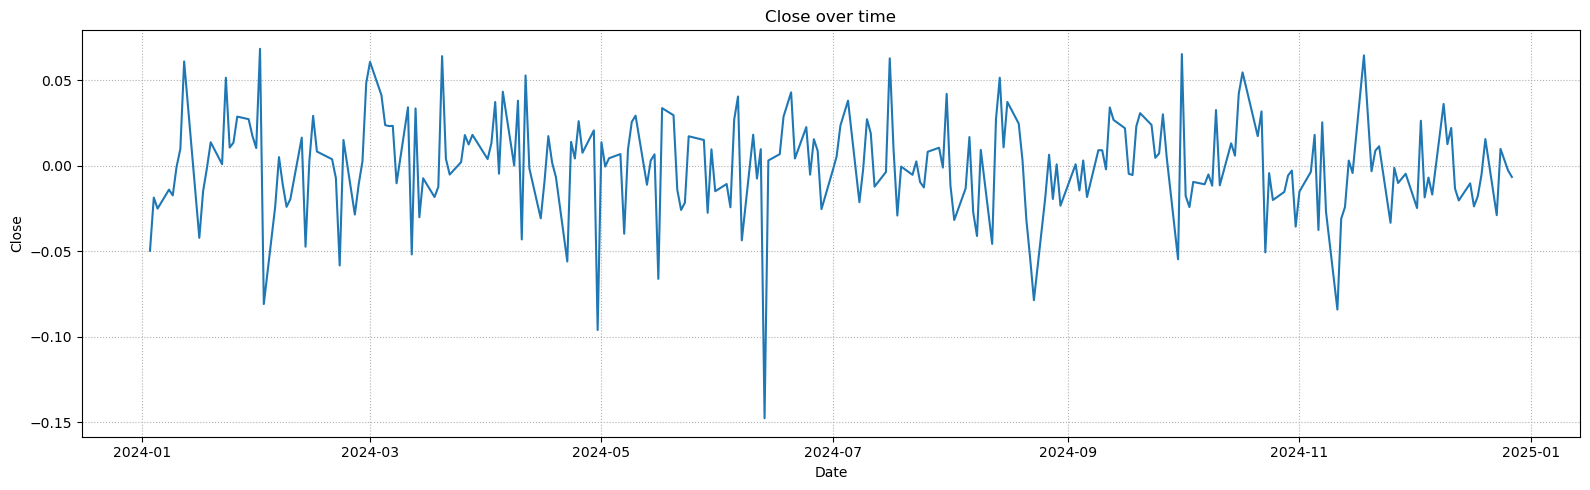

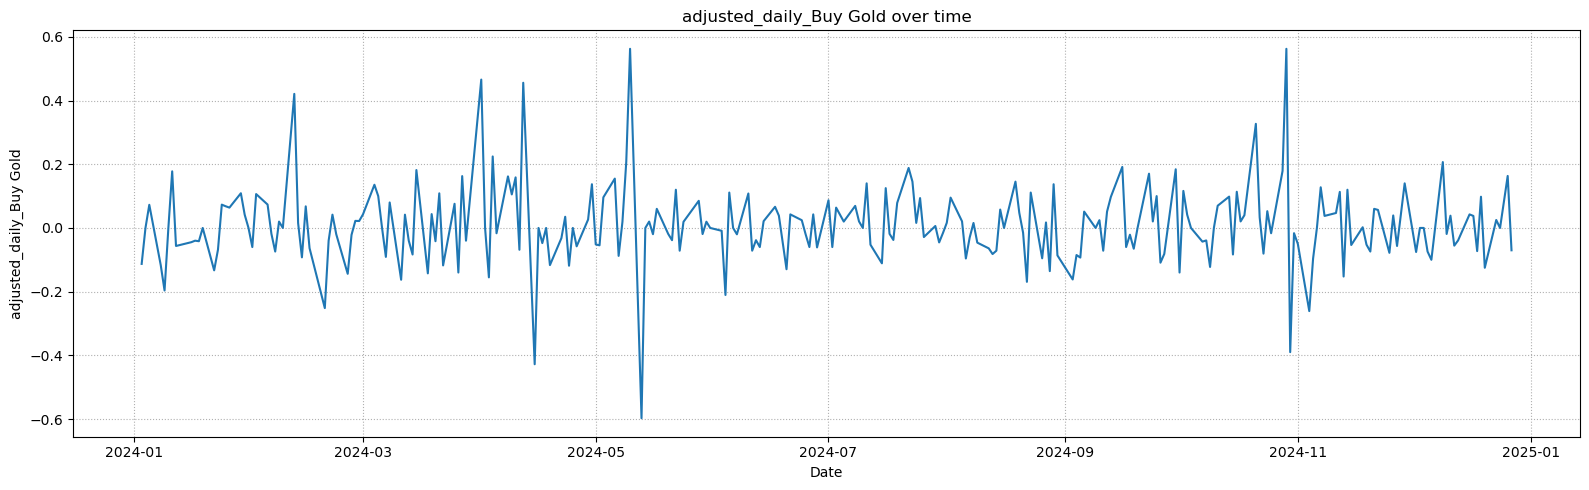

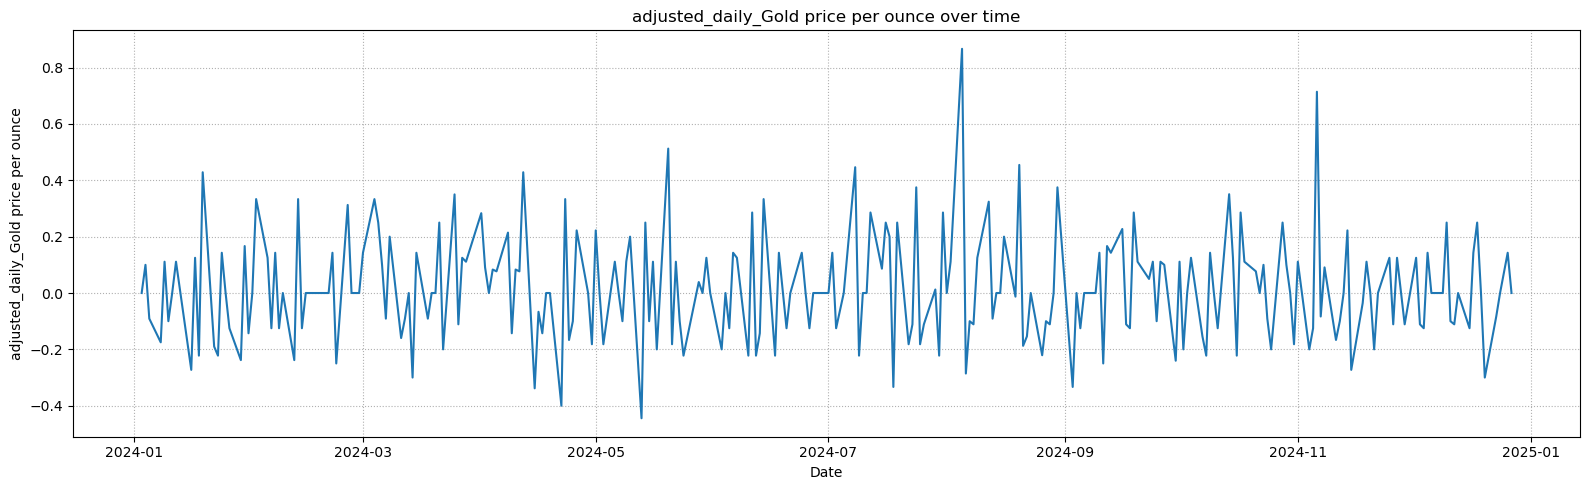

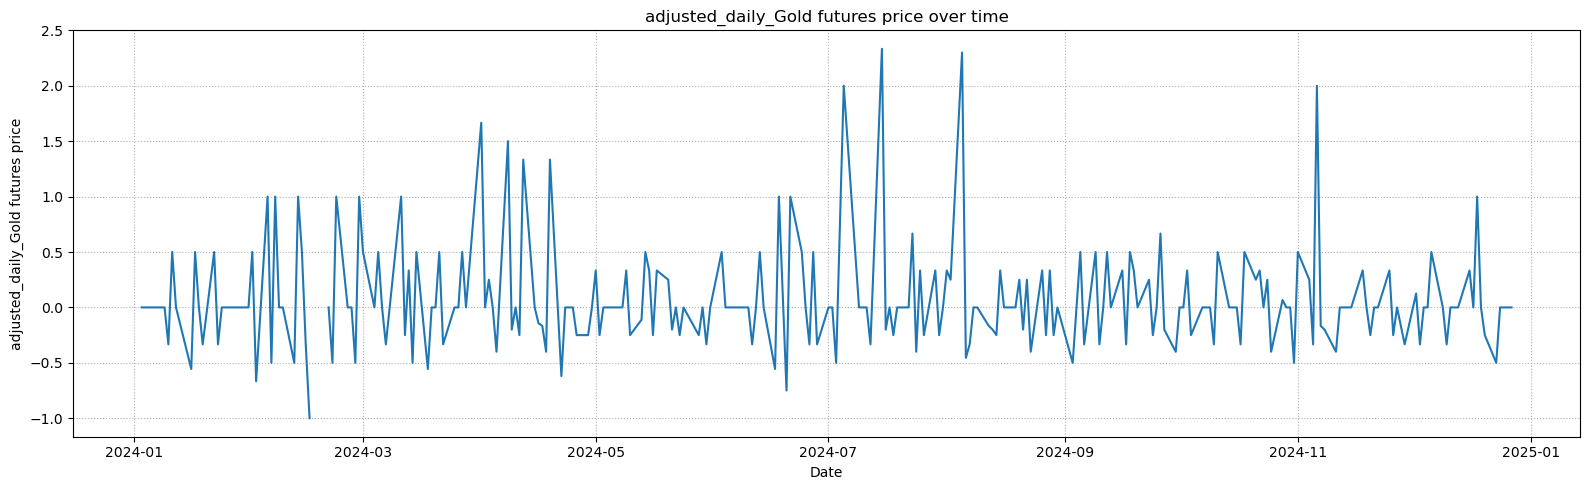

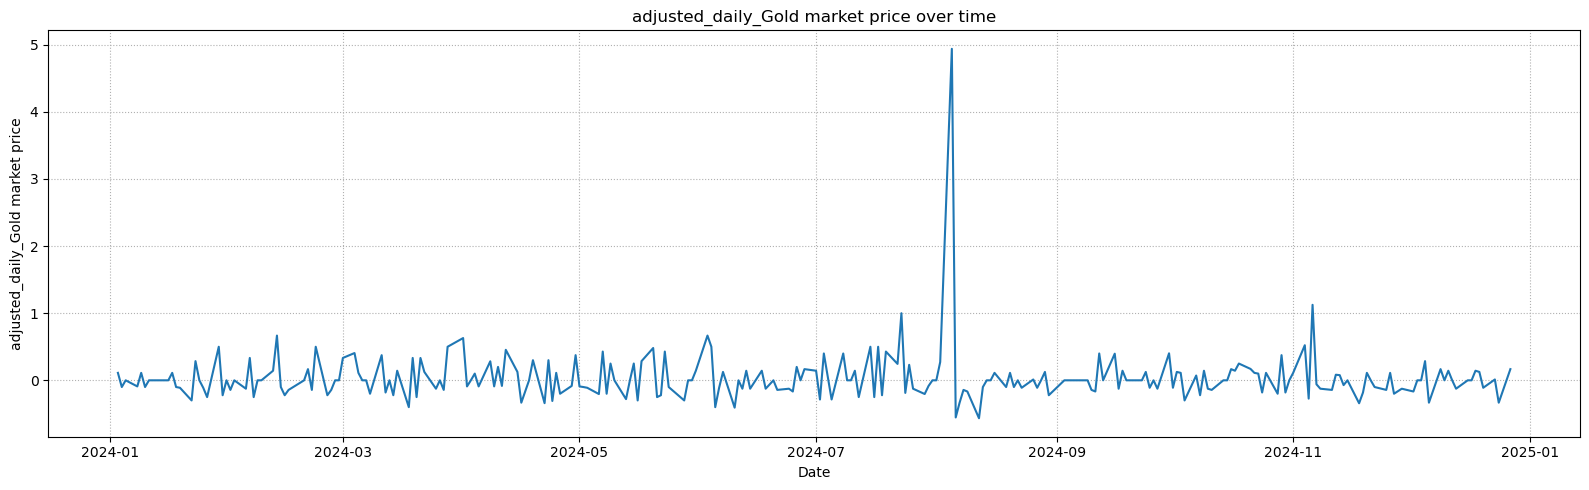

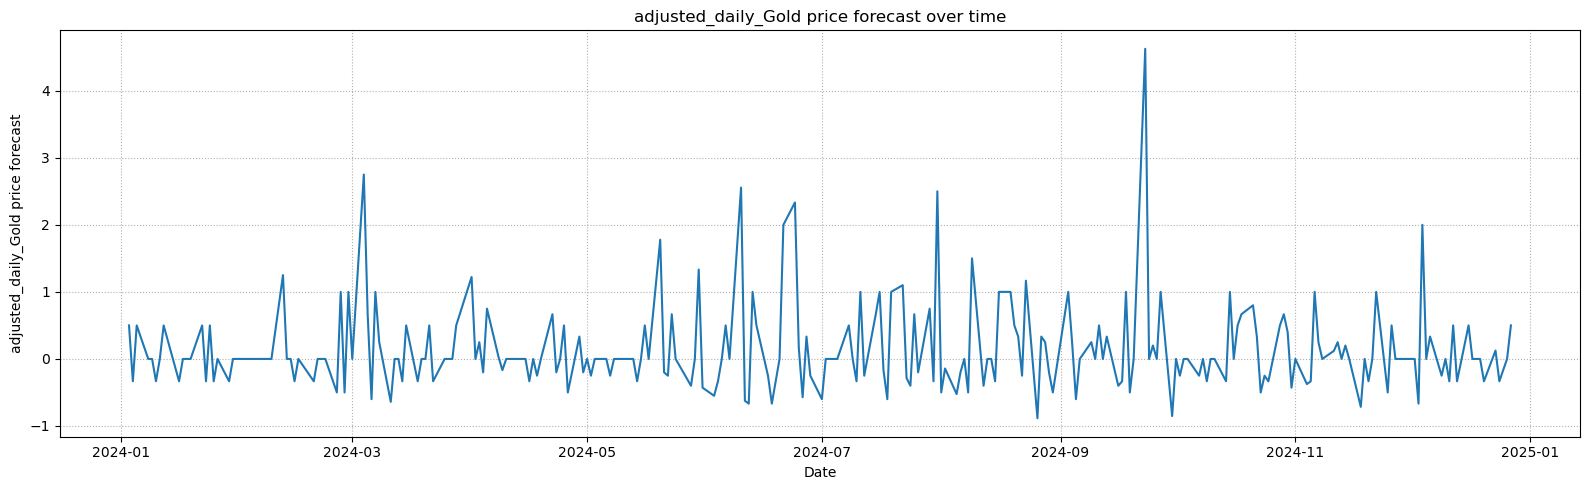

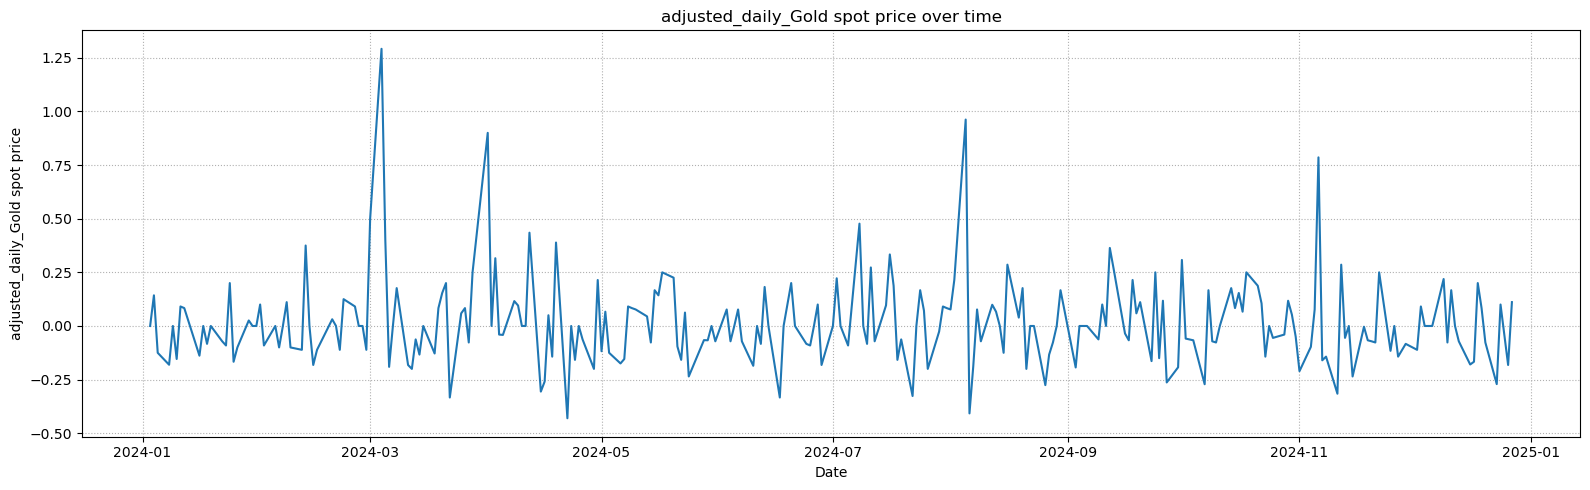

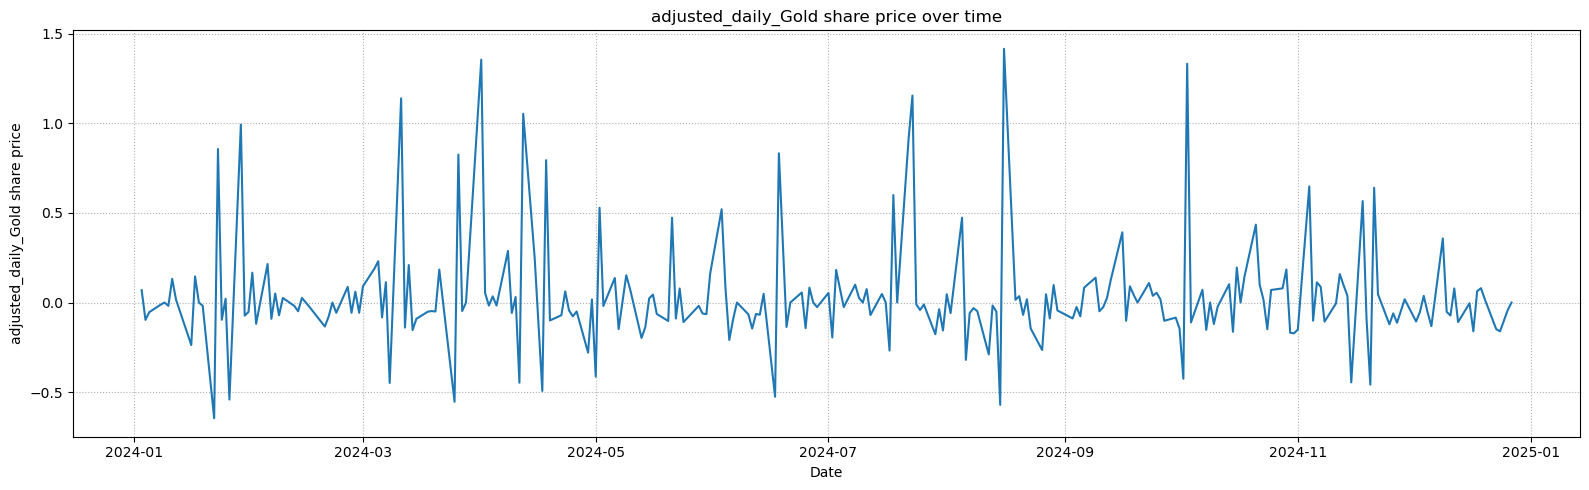

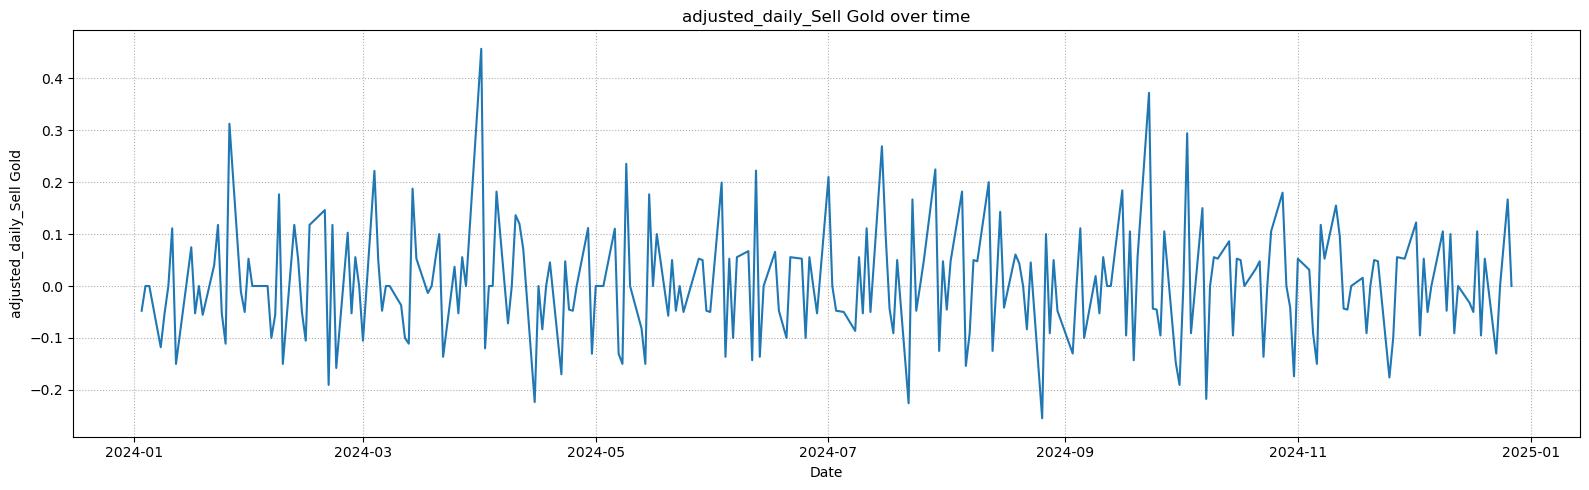

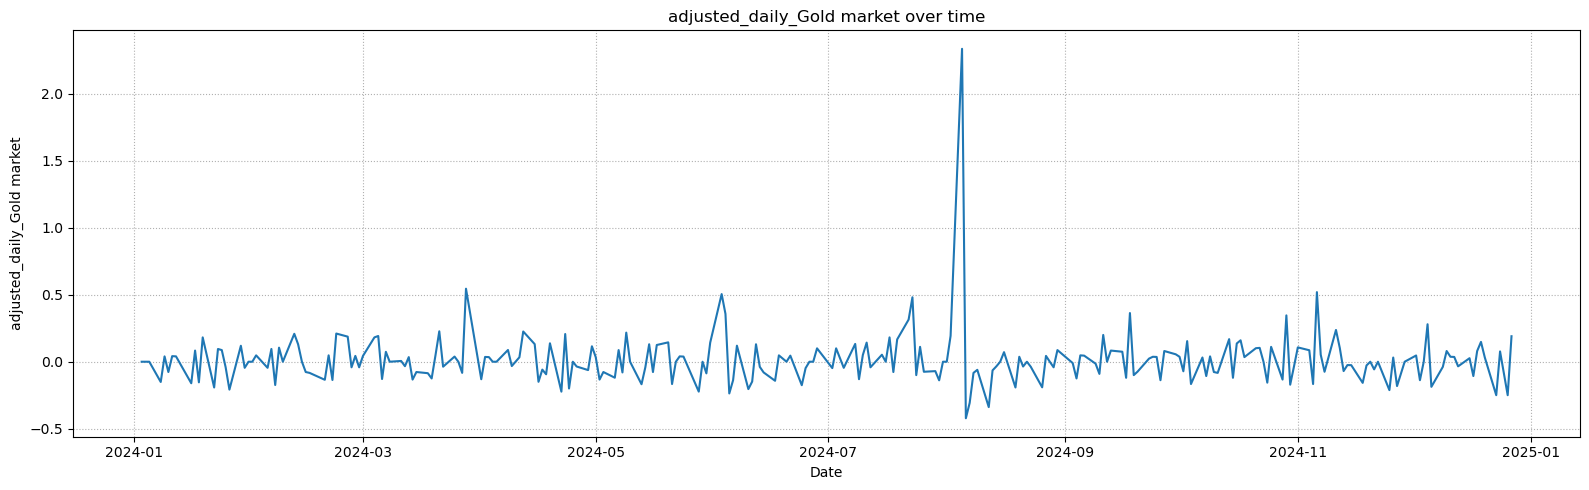

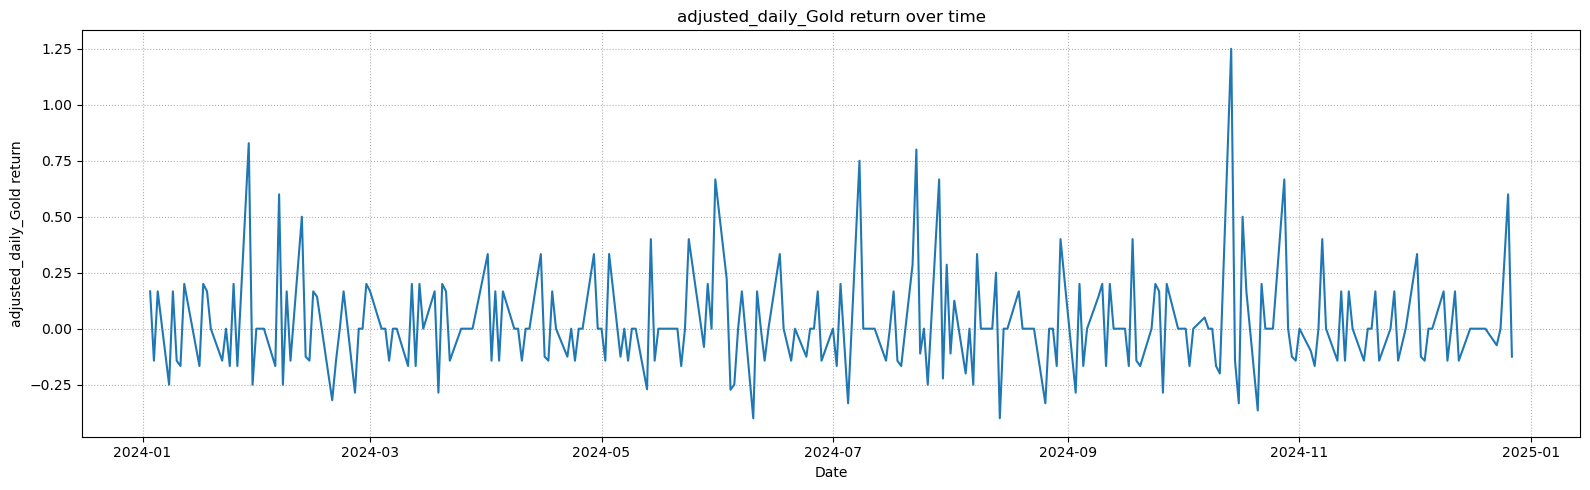

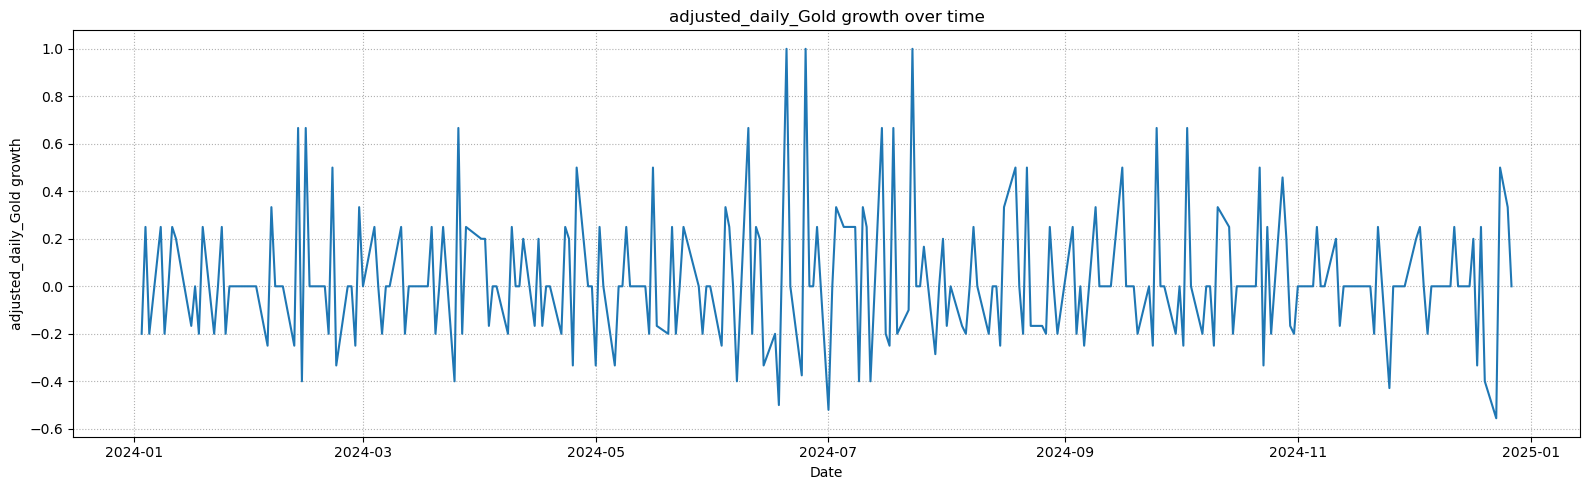

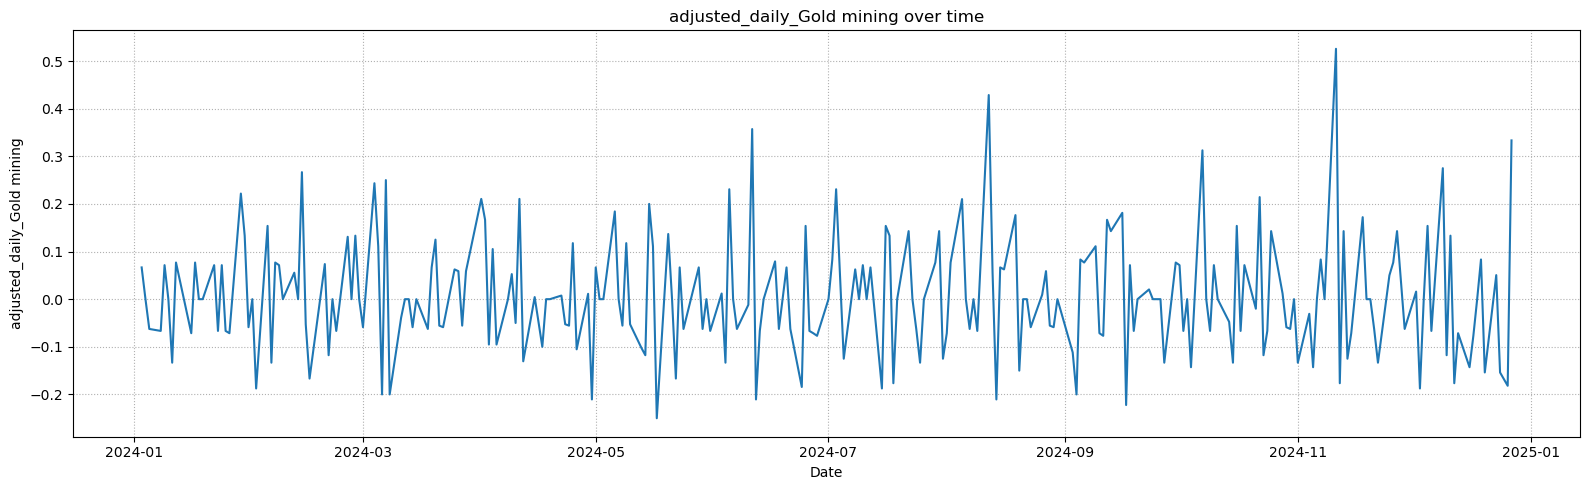

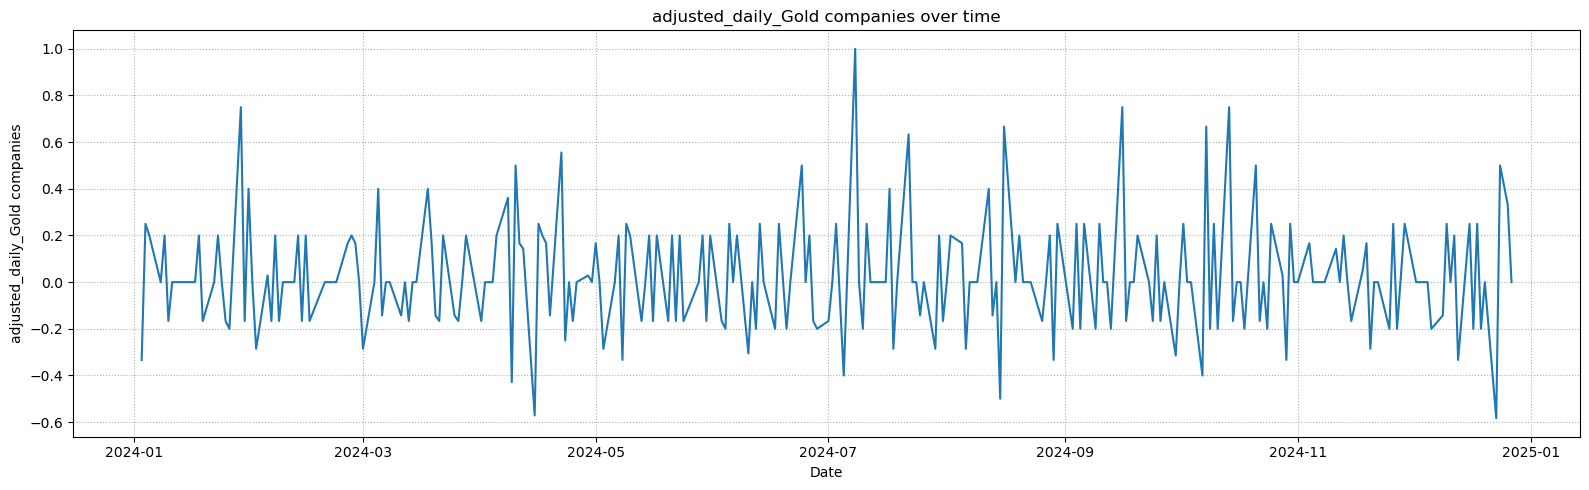

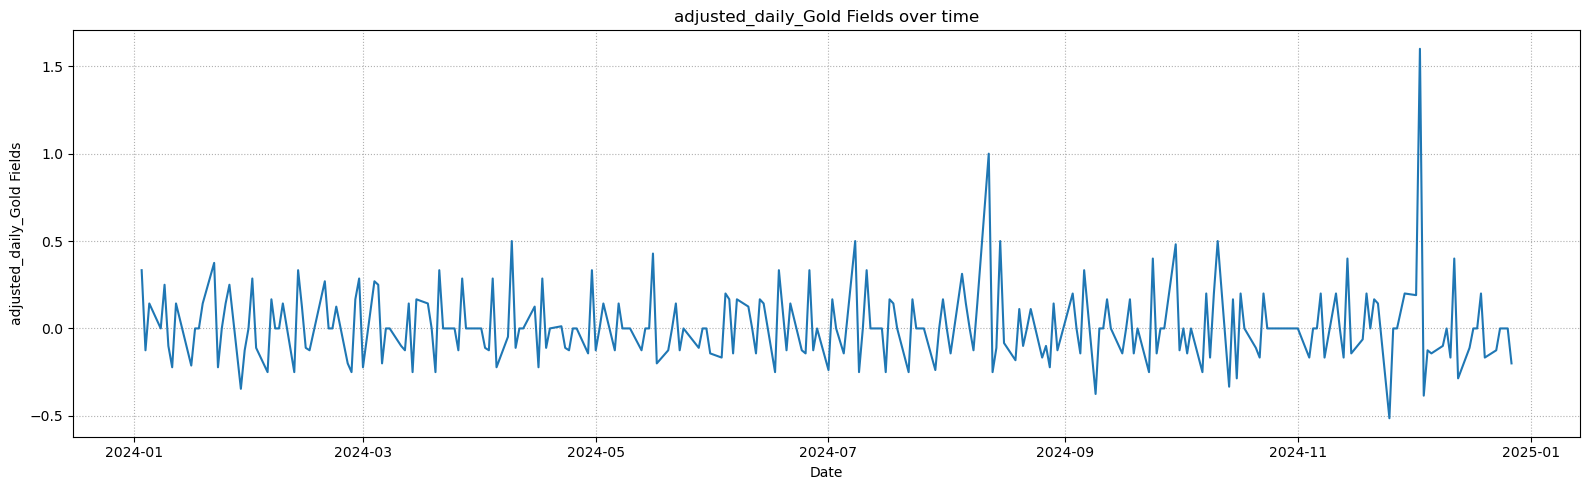

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- your helper (kept as-is) ---
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y)  # no explicit color needed
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# --- prep: make sure Date is datetime & sorted ---
df = df.copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# --- loop all columns except Date ---
cols_to_plot = [c for c in df.columns if c != 'Date']

for col in cols_to_plot:
    # coerce to numeric in case any column is object; plotting will skip NaNs
    y = pd.to_numeric(df[col], errors='coerce')
    if y.notna().sum() == 0:
        print(f"Skipping '{col}' (no numeric data).")
        continue

    plot_df(
        df,
        x=df['Date'],
        y=y,
        title=f"{col} over time",
        xlabel="Date",
        ylabel=col
    )


In [94]:
df

,Date,Close,adjusted_daily_Buy Gold,adjusted_daily_Gold price per ounce,adjusted_daily_Gold futures price,adjusted_daily_Gold market price,adjusted_daily_Gold price forecast,adjusted_daily_Gold spot price,adjusted_daily_Gold share price,adjusted_daily_Sell Gold,adjusted_daily_Gold market,adjusted_daily_Gold return,adjusted_daily_Gold growth,adjusted_daily_Gold mining,adjusted_daily_Gold companies,adjusted_daily_Gold Fields
0,2024-01-03,-0.049787,-0.112903,0.000000,0.00,0.111111,0.500000,0.000000,0.068966,-0.047619,0.000000,0.166667,-0.200000,0.066667,-3.333333e-01,0.333333
1,2024-01-04,-0.018713,0.000000,0.100000,0.00,-0.100000,-0.333333,0.142857,-0.096774,0.000000,0.000000,-0.142857,0.250000,0.000000,2.500000e-01,-0.125000
2,2024-01-05,-0.025172,0.072727,-0.090909,0.00,0.000000,0.500000,-0.125000,-0.053571,0.000000,0.000000,0.166667,-0.200000,-0.062500,2.000000e-01,0.142857
3,2024-01-08,-0.014084,-0.116761,-0.175000,0.00,-0.090909,0.000000,-0.180672,-0.011546,-0.117857,-0.151235,-0.250000,0.250000,-0.066667,-2.220446e-16,0.000000
4,2024-01-09,-0.017460,-0.196429,0.111111,0.00,0.111111,0.000000,0.000000,0.000000,-0.052632,0.040000,0.166667,-0.200000,0.071429,2.000000e-01,0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,2024-12-20,0.015464,-0.125000,-0.300000,-0.25,-0.111111,-0.333333,-0.076923,0.018519,0.052632,0.032258,0.000000,-0.400000,-0.153846,0.000000e+00,-0.166667
245,2024-12-23,-0.029007,0.025000,-0.083333,-0.50,0.012500,0.125000,-0.270833,-0.148733,-0.130000,-0.250000,-0.074074,-0.555556,0.050505,-5.833333e-01,-0.125000
246,2024-12-24,0.009709,0.000000,0.000000,0.00,-0.333333,-0.333333,0.100000,-0.160714,0.000000,0.076923,0.000000,0.500000,-0.153846,5.000000e-01,0.000000
247,2024-12-26,-0.002959,0.163265,0.142857,0.00,0.000000,0.000000,-0.181818,-0.042553,0.166667,-0.250000,0.600000,0.333333,-0.181818,3.333333e-01,0.000000


Check for stationarity

In [96]:
columns = [c for c in df.columns if c != 'Date']

for col in columns:
    s = pd.to_numeric(df[col], errors='coerce').dropna()

    print(f"\n=== {col} ===")


    try:
        result = adfuller(s)  
        print(f'Test Statistics: {result[0]}')
        print(f'p-value: {result[1]}')
        print(f'critical_values: {result[4]}')
        print("Series is stationary" if result[1] <= 0.05 else "Series is not stationary")
    except Exception as e:
        print(f"ADF failed: {e}")


=== Close ===
Test Statistics: -15.114966757498207
p-value: 7.601988562795339e-28
critical_values: {'1%': -3.4569962781990573, '5%': -2.8732659015936024, '10%': -2.573018897632674}
Series is stationary

=== adjusted_daily_Buy Gold ===
Test Statistics: -19.45304766422986
p-value: 0.0
critical_values: {'1%': -3.4569962781990573, '5%': -2.8732659015936024, '10%': -2.573018897632674}
Series is stationary

=== adjusted_daily_Gold price per ounce ===
Test Statistics: -14.333019175311449
p-value: 1.0917605407637497e-26
critical_values: {'1%': -3.457105309726321, '5%': -2.873313676101283, '10%': -2.5730443824681606}
Series is stationary

=== adjusted_daily_Gold futures price ===
Test Statistics: -11.3688667527135
p-value: 9.08319752571246e-21
critical_values: {'1%': -3.4573260719088132, '5%': -2.873410402808354, '10%': -2.573095980841316}
Series is stationary

=== adjusted_daily_Gold market price ===
Test Statistics: -17.637238818784677
p-value: 3.773724669267328e-30
critical_values: {'1%': -

All the series is stationary

In [97]:
# =========================
# Granger causality scanner
# =========================
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

# ---- user params ----
target_col = 'Close'
date_col   = 'Date'          # change if different
maxlag     = 30              # days/lags to scan
alpha      = 0.05            # significance threshold

def _gcause_direction(y: pd.Series, x: pd.Series, maxlag: int):
    """
    Test 'x ⇒ y' for lags 1..maxlag.
    Returns dict: {lag: pvalue} and N used.
    """
    data = pd.concat([y, x], axis=1).dropna()
    data.columns = ['y', 'x']
    # need enough observations
    if len(data) < (maxlag + 8):  # heuristic cushion for regression df
        return {}, len(data)
    try:
        res = grangercausalitytests(data[['y','x']], maxlag=maxlag, verbose=False)
    except Exception:
        # sometimes singular matrices occur; return empty
        return {}, len(data)

    pvals = {}
    for L in range(1, maxlag+1):
        try:
            pvals[L] = res[L][0]['ssr_ftest'][1]   # F-test p-value
        except Exception:
            pvals[L] = np.nan
    return pvals, len(data)

records = []

for col in other_cols:
    # X ⇒ Close
    p_x_to_close, n1 = _gcause_direction(df[target_col], df[col], maxlag)
    if p_x_to_close:
        bestL = min(p_x_to_close, key=lambda k: p_x_to_close[k] if pd.notna(p_x_to_close[k]) else 1.0)
        pmin  = p_x_to_close[bestL]
        records.append({
            'Variable': col,
            'Direction': f'{col} ⇒ {target_col}',
            'Best Lag': bestL,
            'Min p-value': pmin,
            'Significant@α': (pmin is not None) and (pmin < alpha),
            'N_used': n1
        })

    # Close ⇒ X (reverse)
    p_close_to_x, n2 = _gcause_direction(df[col], df[target_col], maxlag)
    if p_close_to_x:
        bestL = min(p_close_to_x, key=lambda k: p_close_to_x[k] if pd.notna(p_close_to_x[k]) else 1.0)
        pmin  = p_close_to_x[bestL]
        records.append({
            'Variable': col,
            'Direction': f'{target_col} ⇒ {col}',
            'Best Lag': bestL,
            'Min p-value': pmin,
            'Significant@α': (pmin is not None) and (pmin < alpha),
            'N_used': n2
        })

# ---- summary table ----
gc_summary = (pd.DataFrame.from_records(records)
              .sort_values(['Significant@α','Min p-value'], ascending=[False, True])
              .reset_index(drop=True))

print("=== Granger Causality Summary ===")
print(gc_summary)


c:\Users\Peet\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Peet\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Peet\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Peet\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Peet\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Peet\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not

=== Granger Causality Summary ===
                               Variable  \
0    adjusted_daily_Gold price forecast   
1   adjusted_daily_Gold price per ounce   
2        adjusted_daily_Gold spot price   
3               adjusted_daily_Buy Gold   
4       adjusted_daily_Gold share price   
5            adjusted_daily_Gold return   
6    adjusted_daily_Gold price forecast   
7            adjusted_daily_Gold growth   
8   adjusted_daily_Gold price per ounce   
9            adjusted_daily_Gold growth   
10           adjusted_daily_Gold return   
11      adjusted_daily_Gold share price   
12             adjusted_daily_Sell Gold   
13           adjusted_daily_Gold mining   
14              adjusted_daily_Buy Gold   
15        adjusted_daily_Gold companies   
16    adjusted_daily_Gold futures price   
17       adjusted_daily_Gold spot price   
18        adjusted_daily_Gold companies   
19     adjusted_daily_Gold market price   
20    adjusted_daily_Gold futures price   
21           adjuste

c:\Users\Peet\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Peet\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
